# Terremoto Chocó 2026-08-10 — Reconstrucción de forma de onda y comparación con estaciones del SGC

Notebook independiente de `post_analysis.ipynb`. Este notebook:

1. **Reconstruye** la hora completa (2026-08-10, ~07:00–08:00 hora local) del
   acelerómetro propio (Universidad de Antioquia, Medellín) combinando la
   grabación continua (`data/aceleraciones/terremoto_choco/`) con los eventos
   capturados por el detector embebido (`data/eventos/terremoto_choco/`),
   rellenando los huecos restantes por interpolación lineal para obtener una
   señal limpia y continua.
2. **Marca** con franjas rojas ("Alerta Detectada") los instantes en que el
   detector propio disparó una alerta.
3. **Compara** esa reconstrucción contra tres acelerógrafos oficiales del SGC:
   **Dabeiba** (`estacion_dabeiba_SGC2026pqqmro_DBB_10.anc` + `DBB.mseed`),
   **Pereira, Risaralda** (`estacion_pereira_SGC2026pqqmro_CBOCA_10.anc` +
   `CBOCA_HN*.mseed`) y **Riosucio, Caldas** (`estacion_riosucio_SGC2026pqqmro_RIO2C_10.anc`
   + `RIO2C.mseed`), en unidades de **g** y de **cm/s²**, tanto por separado
   como superpuestas, y en **hora UTC y hora local de Colombia**. Las figuras
   de cada estación del SGC se guardan en su propia subcarpeta
   (`data/Datos_SGC_Terremoto_Choco/{Dabeiba,Pereira,Riosucio}/`).

### Mapeo de ejes

| Canal firmware (propio) | Canal SGC (`.anc`) | Convención de este notebook |
|---|---|---|
| ax | EW | EW |
| ay | NS | NS |
| az | VER | VER |

### Supuestos documentados

- **Zona horaria**: los nombres de archivo `.bin` están en hora local de
  Colombia (UTC-5). Se verificó comparando la hora de origen del sismo (UTC,
  tomada del `.anc` del SGC) contra los instantes reales en que el detector
  propio disparó alertas: la llegada de onda P/S calculada a partir de la
  distancia epicentral coincide (dentro de ~2 s) con esas alertas solo si se
  asume este desfase de 5 h.
- **Hora de inicio de los registros del SGC**: la cabecera del `.anc` no trae
  un campo explícito de "hora de inicio del registro", solo la hora de origen
  del sismo (`2026-08-10 12:34:27 UTC`). Las primeras versiones de este
  notebook probaron dos supuestos (empieza en la hora de origen; luego, según
  valores leídos manualmente de la página del SGC) que resultaron
  inconsistentes con los datos. La hora real se determinó por **correlación
  cruzada** contra los `.mseed` crudos de cada estación (§12-§15): en las 3
  estaciones, de forma independiente y consistente en los 9 canales
  (R² > 0.99), el registro del `.anc` empieza exactamente **30 s antes** del
  origen del sismo (`12:33:57 UTC`), con ~510 s de datos reales (`NUMERO DE
  DATOS` × `INTERVALO DE MUESTREO`) -- esa es la duración real que se
  grafica, aunque el sitio del SGC pueda mostrar un eje de tiempo más ancho.


## §1 — Importaciones

In [1]:
import re
import struct
import pathlib
import warnings
from datetime import datetime, timedelta, timezone

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## §2 — Configuración

> Única celda que normalmente habría que editar si cambian las rutas de entrada.

In [2]:
# -- Rutas de entrada ----------------------------------------------------------
DIR_ACEL    = pathlib.Path("data/aceleraciones/terremoto_choco")
DIR_EVENTOS = pathlib.Path("data/eventos/terremoto_choco")
RUTA_ANC_DABEIBA  = pathlib.Path("data/Datos_SGC_Terremoto_Choco/estacion_dabeiba_SGC2026pqqmro_DBB_10.anc")
RUTA_ANC_PEREIRA  = pathlib.Path("data/Datos_SGC_Terremoto_Choco/estacion_pereira_SGC2026pqqmro_CBOCA_10.anc")
RUTA_ANC_RIOSUCIO = pathlib.Path("data/Datos_SGC_Terremoto_Choco/estacion_riosucio_SGC2026pqqmro_RIO2C_10.anc")
RUTA_MSEED_DABEIBA_TODO  = pathlib.Path("data/Datos_SGC_Terremoto_Choco/DBB.mseed")
RUTA_MSEED_RIOSUCIO_TODO = pathlib.Path("data/Datos_SGC_Terremoto_Choco/RIO2C.mseed")

# -- Hora real de inicio de cada registro del SGC ------------------------------
# El .anc NO trae un campo de "hora de inicio del registro" (solo la hora de
# origen del sismo), así que no se puede derivar del archivo por sí solo. Se
# determinó por correlación cruzada contra los .mseed crudos de cada estación
# (ver §12-§15): en las 3 estaciones, de forma independiente y consistente en
# los 9 canales (R² > 0.99), el registro real del .anc empieza exactamente
# 30 s antes del origen del sismo (12:34:27 UTC) -- así que las 3 comparten
# el mismo instante de inicio.
INICIO_DABEIBA_UTC  = datetime(2026, 8, 10, 12, 33, 57, 0, tzinfo=timezone.utc)
INICIO_PEREIRA_UTC  = datetime(2026, 8, 10, 12, 33, 57, 0, tzinfo=timezone.utc)
INICIO_RIOSUCIO_UTC = datetime(2026, 8, 10, 12, 33, 57, 0, tzinfo=timezone.utc)

# -- Rutas de salida -- una subcarpeta por estación ------------------------------
DIR_OUT_PLOTS = pathlib.Path("output/plots")
DIR_SGC_OUT   = pathlib.Path("data/Datos_SGC_Terremoto_Choco")
DIR_DABEIBA   = DIR_SGC_OUT / "Dabeiba"
DIR_PEREIRA   = DIR_SGC_OUT / "Pereira"
DIR_RIOSUCIO  = DIR_SGC_OUT / "Riosucio"
for _d in [DIR_OUT_PLOTS, DIR_DABEIBA, DIR_PEREIRA, DIR_RIOSUCIO]:
    _d.mkdir(parents=True, exist_ok=True)

# -- Constantes del sensor (idénticas a post_analysis.ipynb) --------------------
MAGIC     = 0xDA7A1345   # número mágico del formato .bin
SCALE_G   = 0.0039       # g/LSB -- ADXL345 +-2g full-resolution
G_TO_CMS2 = 980.665      # factor de conversión g -> cm/s^2
FS        = 200          # Hz -- frecuencia de muestreo

# -- Zona horaria -----------------------------------------------------------------
# Ver supuesto documentado en la introducción del notebook.
TZ_OFFSET_HORAS = -5

# -- Componentes (orden de las columnas de datos, no cambia) --------------------
_LABELS = ["EW", "NS", "VER"]

# -- Identificadores de red/estación, estilo NSLC (Red.Estación.Localización) --
# El de Dabeiba ("CM.DBB.10") es el que usa el propio SGC en sus gráficas
# oficiales (visible en la cabecera del .anc y confirmado por el usuario). Para
# Pereira se asume el mismo código de red/localización ("CM"/"10"), ya que es
# la misma Red Nacional de Acelerógrafos; el código de estación (CBOCA) sí
# viene directo de la cabecera del .anc.
RED_PROPIA, ESTACION_PROPIA, LOC_PROPIA = "PAN", "PANUDEA01", ""
RED_SGC,    ESTACION_SGC,    LOC_SGC    = "CM",  "DBB",   "10"
RED_PEREIRA,  ESTACION_PEREIRA,  LOC_PEREIRA  = "CM", "CBOCA", "10"
RED_RIOSUCIO, ESTACION_RIOSUCIO, LOC_RIOSUCIO = "CM", "RIO2C", "10"
ID_PROPIA   = f"{RED_PROPIA}.{ESTACION_PROPIA}.{LOC_PROPIA}"
ID_SGC      = f"{RED_SGC}.{ESTACION_SGC}.{LOC_SGC}"
ID_PEREIRA  = f"{RED_PEREIRA}.{ESTACION_PEREIRA}.{LOC_PEREIRA}"
ID_RIOSUCIO = f"{RED_RIOSUCIO}.{ESTACION_RIOSUCIO}.{LOC_RIOSUCIO}"

# -- Canal por componente y orden de filas (Z, N, E -- convención SGC/ObsPy) ----
_CANAL_POR_COMP = {"EW": "E", "NS": "N", "VER": "Z"}
_ORDEN_FILAS    = ["VER", "NS", "EW"]

# -- Colores: negro para trazas individuales (igual que el formato oficial del
#    SGC); rojo solo se usa para distinguir la traza del SGC cuando se
#    superpone con la propia; ámbar para las franjas de alerta -----------------
COLOR_PROPIA = "black"
COLOR_SGC    = "#D32F2F"
COLOR_ALERTA = "#FFB300"

print("Configuración cargada.")
print(f"  Aceleraciones : {DIR_ACEL}")
print(f"  Eventos       : {DIR_EVENTOS}")
print(f"  Archivo SGC Dabeiba  : {RUTA_ANC_DABEIBA}")
print(f"  Archivo SGC Pereira  : {RUTA_ANC_PEREIRA}")
print(f"  Archivo SGC Riosucio : {RUTA_ANC_RIOSUCIO}")


Configuración cargada.
  Aceleraciones : data\aceleraciones\terremoto_choco
  Eventos       : data\eventos\terremoto_choco
  Archivo SGC Dabeiba  : data\Datos_SGC_Terremoto_Choco\estacion_dabeiba_SGC2026pqqmro_DBB_10.anc
  Archivo SGC Pereira  : data\Datos_SGC_Terremoto_Choco\estacion_pereira_SGC2026pqqmro_CBOCA_10.anc
  Archivo SGC Riosucio : data\Datos_SGC_Terremoto_Choco\estacion_riosucio_SGC2026pqqmro_RIO2C_10.anc


## §3 — Parser del formato `.bin` (acelerómetro propio)

Reimplementación autónoma de `parse_bin()` de `post_analysis.ipynb` §4 (mismo
formato ESP32: cabecera `MAGIC/VERSION/SAMPLE_RATE(+lat/lon)` + muestras de
10 bytes `timestamp_ms, ax, ay, az`).

In [3]:
_HEADER_V2   = 8    # MAGIC(4) + VERSION(2) + SAMPLE_RATE(2)
_HEADER_V3   = 16   # V2 + lat(4) + lon(4)
_SAMPLE_SIZE = 10   # timestamp_ms(4) + ax(2) + ay(2) + az(2)


def parse_bin(path):
    """
    Lee un archivo .bin del ESP32 (formato PANdeMaiz Quake).

    Retorna
    -------
    header : dict  {version, sample_rate, lat, lon}
    data   : ndarray (N, 4) float32  [t_s, ax_g, ay_g, az_g]
    """
    raw = pathlib.Path(path).read_bytes()

    if len(raw) < _HEADER_V2:
        raise ValueError(f"{path}: archivo demasiado corto ({len(raw)} bytes)")

    magic, version, sr = struct.unpack_from("<IHH", raw, 0)
    if magic != MAGIC:
        raise ValueError(f"{path}: magic inválido 0x{magic:08X} (esperado 0x{MAGIC:08X})")

    if version >= 3 and len(raw) >= _HEADER_V3:
        lat, lon = struct.unpack_from("<ff", raw, 8)
        hdr_size = _HEADER_V3
    else:
        lat, lon = 0.0, 0.0
        hdr_size = _HEADER_V2

    header = {"version": version, "sample_rate": int(sr), "lat": lat, "lon": lon}

    n_samples = (len(raw) - hdr_size) // _SAMPLE_SIZE
    samples = []
    pos = hdr_size
    for _ in range(n_samples):
        ts_ms, ax, ay, az = struct.unpack_from("<Ihhh", raw, pos)
        samples.append([ts_ms / 1000.0, ax * SCALE_G, ay * SCALE_G, az * SCALE_G])
        pos += _SAMPLE_SIZE

    if not samples:
        raise ValueError(f"{path}: no contiene muestras")

    return header, np.array(samples, dtype=np.float32)


def get_starttime_local(stem):
    """Extrae datetime local (hora de Colombia, naive) del patrón 'YYYYMMDD_HHMMSS'."""
    m = re.search(r"(\d{8})_(\d{6})", stem)
    if m:
        try:
            return datetime.strptime(m.group(1) + m.group(2), "%Y%m%d%H%M%S")
        except ValueError:
            pass
    return None


def local_to_utc(dt_local_naive):
    """Convierte un datetime naive en hora local de Colombia a UTC (aware)."""
    return dt_local_naive.replace(tzinfo=timezone(timedelta(hours=TZ_OFFSET_HORAS))).astimezone(timezone.utc)


def discover_bins(folder):
    folder = pathlib.Path(folder)
    files = sorted(folder.glob("*.bin"))
    if not files:
        print(f"[AVISO] No se encontraron archivos .bin en: {folder}")
    return files


print("parse_bin(), get_starttime_local(), local_to_utc() y discover_bins() definidas.")


parse_bin(), get_starttime_local(), local_to_utc() y discover_bins() definidas.


## §4 — Reconstrucción de la hora completa (señal limpia)

Combina `aceleraciones` (prioridad máxima) + `eventos` (rellena huecos donde
encajan) + interpolación lineal para el resto de los huecos. Devuelve también
las ventanas de alerta para resaltarlas en todas las gráficas del acelerómetro
propio.

In [4]:
def _extraer_score(stem):
    m = re.search(r"_s(\d+)$", stem)
    return m.group(1) if m else "?"


def reconstruct_full_hour(accel_paths, evento_paths, fs=FS):
    """
    Reconstruye una señal continua a `fs` Hz en UTC combinando los archivos de
    grabación continua (aceleraciones) con los archivos de eventos/alertas,
    rellenando los huecos restantes por interpolación lineal.

    Retorna un dict:
      t_utc         : ndarray datetime64[us], longitud N
      data_g        : ndarray (N, 3) float64  [EW, NS, VER] en g, línea base removida
      status        : ndarray (N,) int8  0=vacío 1=continuo 2=evento 3=interpolado
      alert_windows : list of (inicio_utc, fin_utc, score) -- una por archivo de eventos
      resumen       : dict con segundos totales / huecos / rellenados por evento / interpolados
    """
    if not accel_paths:
        raise ValueError("reconstruct_full_hour: no hay archivos de aceleraciones")

    dt = 1.0 / fs

    accel_info = []
    for p in accel_paths:
        t_local = get_starttime_local(p.stem)
        if t_local is None:
            warnings.warn(f"{p.name}: no se pudo extraer fecha/hora del nombre, se omite.")
            continue
        t0_utc = local_to_utc(t_local)
        _, data = parse_bin(p)
        accel_info.append((t0_utc, len(data), data))

    if not accel_info:
        raise ValueError("reconstruct_full_hour: ningún archivo de aceleraciones pudo procesarse")

    accel_info.sort(key=lambda x: x[0])
    t_inicio_hora = accel_info[0][0]
    t_fin_hora    = accel_info[-1][0] + timedelta(seconds=accel_info[-1][1] / fs)
    n_total = int(round((t_fin_hora - t_inicio_hora).total_seconds() / dt)) + 1

    data_g = np.full((n_total, 3), np.nan, dtype=np.float64)
    status = np.zeros(n_total, dtype=np.int8)   # 0=vacío 1=continuo 2=evento 3=interpolado

    def _volcar(t0_utc, arr_n4, codigo, permitir_sobrescribir):
        offset = int(round((t0_utc - t_inicio_hora).total_seconds() / dt))
        n = len(arr_n4)
        idx = np.arange(offset, offset + n)
        valido = (idx >= 0) & (idx < n_total)
        idx = idx[valido]
        vals = arr_n4[valido][:, 1:4]  # ax, ay, az -> EW, NS, VER
        if not permitir_sobrescribir:
            libres = status[idx] == 0
            idx, vals = idx[libres], vals[libres]
        data_g[idx] = vals
        status[idx] = codigo

    # -- 1) Volcar la grabación continua (prioridad máxima) --
    for t0_utc, _, data in accel_info:
        _volcar(t0_utc, data, codigo=1, permitir_sobrescribir=True)

    seg_huecos_original = float(np.sum(status == 0)) * dt

    # -- 2) Rellenar huecos con los archivos de eventos, donde encajen --
    alert_windows = []
    for p in evento_paths:
        t_local = get_starttime_local(p.stem)
        if t_local is None:
            continue
        t0_utc = local_to_utc(t_local)
        _, data = parse_bin(p)
        n = len(data)
        alert_windows.append((t0_utc, t0_utc + timedelta(seconds=n / fs), _extraer_score(p.stem)))
        _volcar(t0_utc, data, codigo=2, permitir_sobrescribir=False)

    huecos_antes_interp = status == 0
    seg_rellenados_evento = seg_huecos_original - float(np.sum(huecos_antes_interp)) * dt

    # -- 3) Interpolación lineal de los huecos restantes --
    idx_todos = np.arange(n_total)
    for c in range(3):
        vacio = np.isnan(data_g[:, c])
        conocido = ~vacio
        if vacio.any() and conocido.sum() >= 2:
            data_g[vacio, c] = np.interp(idx_todos[vacio], idx_todos[conocido], data_g[conocido, c])
    status[huecos_antes_interp] = 3
    seg_interpolados = float(np.sum(huecos_antes_interp)) * dt

    # -- 4) Corrección de línea base: resta la media de un tramo tranquilo --
    #       (primeros 20 s de la hora, lejos del sismo)
    n_baseline = int(20 * fs)
    baseline = np.nanmean(data_g[:n_baseline], axis=0)
    data_g = data_g - baseline

    t_inicio_naive = t_inicio_hora.replace(tzinfo=None)
    t_utc = np.datetime64(t_inicio_naive) + (np.arange(n_total) * dt * 1e6).astype("int64").astype("timedelta64[us]")

    resumen = {
        "segundos_totales": n_total * dt,
        "segundos_hueco_original": seg_huecos_original,
        "segundos_rellenados_evento": seg_rellenados_evento,
        "segundos_interpolados": seg_interpolados,
    }

    return {
        "t_utc": t_utc,
        "data_g": data_g,
        "status": status,
        "alert_windows": alert_windows,
        "resumen": resumen,
    }


print("reconstruct_full_hour() definida.")


reconstruct_full_hour() definida.


In [5]:
accel_files  = discover_bins(DIR_ACEL)
evento_files = discover_bins(DIR_EVENTOS)

print(f"Archivos aceleraciones : {len(accel_files)}")
print(f"Archivos eventos       : {len(evento_files)}")

recon = reconstruct_full_hour(accel_files, evento_files)

r = recon["resumen"]
print("\n-- Resumen de reconstrucción --------------------------------")
print(f"  Duración total reconstruida : {r['segundos_totales']:.1f} s")
print(f"  Hueco original (sin datos)  : {r['segundos_hueco_original']:.2f} s")
print(f"  Rellenado con eventos       : {r['segundos_rellenados_evento']:.2f} s")
print(f"  Rellenado por interpolación : {r['segundos_interpolados']:.2f} s")
print(f"  Alertas detectadas          : {len(recon['alert_windows'])}")
for t0, t1, score in recon["alert_windows"]:
    print(f"    {t0.strftime('%Y-%m-%d %H:%M:%S')} UTC -> {t1.strftime('%H:%M:%S')} UTC  (score s{score})")


Archivos aceleraciones : 58
Archivos eventos       : 6



-- Resumen de reconstrucción --------------------------------
  Duración total reconstruida : 3590.0 s
  Hueco original (sin datos)  : 110.00 s
  Rellenado con eventos       : 4.00 s
  Rellenado por interpolación : 106.00 s
  Alertas detectadas          : 6
    2026-08-10 12:25:27 UTC -> 12:25:31 UTC  (score s94)
    2026-08-10 12:34:52 UTC -> 12:34:56 UTC  (score s97)
    2026-08-10 12:35:03 UTC -> 12:35:07 UTC  (score s99)
    2026-08-10 12:35:13 UTC -> 12:35:17 UTC  (score s99)
    2026-08-10 12:35:27 UTC -> 12:35:31 UTC  (score s99)
    2026-08-10 12:36:15 UTC -> 12:36:19 UTC  (score s99)


## §5 — Parser del formato `.anc` (SGC)

No existía un parser de este formato en el repo (`README.md` lo referencia como
`parse_anc()` pero el notebook que debía definirlo nunca se creó). Implementación
nueva: 19 líneas de metadatos `clave: valor` + 1 línea de encabezado de columnas
+ N filas de datos en cm/s².

**Corrección de hora de inicio**: el archivo `.anc` no trae un campo de "hora
de inicio del registro" (solo la hora de origen del sismo). Se determinó por
correlación cruzada contra los `.mseed` crudos (§12-§15) que las 3 estaciones
(Dabeiba, Pereira, Riosucio) empiezan exactamente 30 s antes del origen del
sismo (`12:33:57 UTC`). Por eso `parse_anc()` recibe la hora de inicio como
parámetro explícito en vez de derivarla del archivo.

In [6]:
def parse_anc(path, inicio_registro_utc):
    """
    Lee un archivo .anc del SGC (Red Nacional de Acelerógrafos de Colombia).

    `inicio_registro_utc` es la hora real (UTC, tz-aware) de la primera
    muestra del archivo -- el .anc no trae este dato en su cabecera (solo la
    hora de origen del sismo), así que se debe indicar explícitamente.

    Retorna
    -------
    header    : dict con metadatos (lat/lon estación y evento, distancia
                epicentral, intervalo de muestreo, número de datos, hora de
                origen del evento en UTC, magnitud, etc.)
    data_cms2 : ndarray (N, 3) float64  [EW, NS, VER] -- reordenada para
                coincidir con la convención EW/NS/VER del notebook
    data_g    : ndarray (N, 3) float64  [EW, NS, VER] -- misma señal en g
    t_utc     : ndarray datetime64[us]  -- eje de tiempo UTC, construido a
                partir de `inicio_registro_utc`
    cols      : list[str]  orden de columnas tal como aparece en el archivo
    """
    path = pathlib.Path(path)
    try:
        texto = path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        texto = path.read_text(encoding="latin-1")

    lineas = texto.splitlines()
    meta_lineas, linea_cols, datos_lineas = lineas[:19], lineas[19], lineas[20:]

    def _valor_float(linea):
        return float(re.search(r"[-+]?\d+\.?\d*", linea.split(":")[-1]).group())

    header = {}

    m = re.search(r"(\d{4}-\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2})\s+M=([\d.]+)", meta_lineas[1])
    if not m:
        raise ValueError(f"{path}: no se pudo extraer fecha/hora/magnitud de la línea 2 de la cabecera")
    fecha, hora, mag = m.groups()
    header["evento_datetime_utc"] = datetime.strptime(f"{fecha} {hora}", "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
    header["magnitud"]             = float(mag)
    header["descripcion_evento"]   = meta_lineas[1][:m.start()].strip(" -")

    header["lat_evento"]            = _valor_float(meta_lineas[2])
    header["lon_evento"]            = _valor_float(meta_lineas[3])
    header["profundidad_km"]        = _valor_float(meta_lineas[4])
    header["codigo_estacion"]       = meta_lineas[5].split(":")[-1].strip()
    header["lat_estacion"]          = _valor_float(meta_lineas[7])
    header["lon_estacion"]          = _valor_float(meta_lineas[8])
    header["distancia_epicentral"]  = _valor_float(meta_lineas[9])
    header["distancia_hipocentral"] = _valor_float(meta_lineas[10])
    header["sample_dt"]             = _valor_float(meta_lineas[11])
    header["n_datos"]               = int(_valor_float(meta_lineas[12]))
    header["duracion_s"]            = _valor_float(meta_lineas[13])
    header["sample_rate"]           = round(1.0 / header["sample_dt"])

    cols = [c.strip().upper() for c in linea_cols.split()]
    datos_raw = np.array(
        [[float(x) for x in linea.split()] for linea in datos_lineas if linea.strip()],
        dtype=np.float64,
    )
    if datos_raw.shape[1] != len(cols):
        raise ValueError(f"{path}: {datos_raw.shape[1]} columnas de datos vs. {len(cols)} en el encabezado")

    idx_reorden = [cols.index(c) for c in _LABELS]  # reordena a [EW, NS, VER]
    data_cms2 = datos_raw[:, idx_reorden]
    data_g    = data_cms2 / G_TO_CMS2

    t0_naive = inicio_registro_utc.astimezone(timezone.utc).replace(tzinfo=None)
    t_utc = np.datetime64(t0_naive) + (np.arange(len(data_cms2)) * header["sample_dt"] * 1e6).astype("int64").astype("timedelta64[us]")

    return header, data_cms2, data_g, t_utc, cols


print("parse_anc() definida.")


parse_anc() definida.


In [7]:
header_sgc, sgc_cms2, sgc_g, t_utc_sgc, cols_sgc = parse_anc(RUTA_ANC_DABEIBA, INICIO_DABEIBA_UTC)

assert sgc_cms2.shape == (header_sgc["n_datos"], 3), "Número de filas/columnas inesperado en el .anc"

print("-- Cabecera SGC -- Estación Dabeiba (DBB) --------------------")
print(f"  Evento               : {header_sgc['descripcion_evento']}")
print(f"  Origen del sismo (UTC): {header_sgc['evento_datetime_utc']}  M={header_sgc['magnitud']}")
print(f"  Inicio del registro  : {t_utc_sgc[0]}  ->  fin: {t_utc_sgc[-1]}  UTC")
print(f"  Estación             : {header_sgc['codigo_estacion']}  lat={header_sgc['lat_estacion']}  lon={header_sgc['lon_estacion']}")
print(f"  Distancia epicentral : {header_sgc['distancia_epicentral']} km")
print(f"  Muestras             : {header_sgc['n_datos']}  ({header_sgc['sample_rate']} Hz, {header_sgc['duracion_s']} s)")
print(f"  Columnas en archivo  : {cols_sgc}")

# -- Nombres para el encabezado de las gráficas (ubicación / magnitud / estaciones) --
# El campo de la cabecera del .anc tiene las tildes reemplazadas por "?" (defecto
# del archivo de origen); se corrige aquí para el título, ya que se conoce el
# nombre real del evento.
_lugar = (header_sgc["descripcion_evento"]
          .replace("Jos?", "José").replace("Choc?", "Chocó").replace(", Colombia", ""))
UBICACION_EVENTO = f"Terremoto — {_lugar}"
MAGNITUD_EVENTO  = f"Magnitud {header_sgc['magnitud']}"

ESTACIONES_PROPIA = "Acelerómetro UdeA (Medellín)"
ESTACIONES_SGC    = "SGC — Estación Dabeiba"
ESTACIONES_AMBAS  = "Acelerómetro UdeA  vs.  SGC — Estación Dabeiba"


-- Cabecera SGC -- Estación Dabeiba (DBB) --------------------
  Evento               : San Jos? del Palmar - Choc?, Colombia
  Origen del sismo (UTC): 2026-08-10 12:34:27+00:00  M=7.4
  Inicio del registro  : 2026-08-10T12:33:57.000000  ->  fin: 2026-08-10T12:42:27.000000  UTC
  Estación             : DBB  lat=7.018  lon=-76.21
  Distancia epicentral : 226.0 km
  Muestras             : 102001  (200 Hz, 510.0 s)
  Columnas en archivo  : ['EW', 'VER', 'NS']


## §6 — Función de graficación reutilizable (formato oficial SGC / ObsPy)

Un solo panel de 3 filas, con el **mismo tamaño de figura (900x900 px) que las
gráficas oficiales del SGC**, la **misma escala de eje Y en los 3 paneles**,
traza(s) en negro (rojo solo si se superpone la traza del SGC) con una
**leyenda que diferencia Acelerómetro UdeA (negro) de SGC (rojo)**, casilla
con el código `Red.Estación.Localización.Canal` en la esquina superior
izquierda, filas en orden **Z, N, E**, y un encabezado de 5 líneas: **ubicación**
del evento, **magnitud**, **estaciones** comparadas, y los subtítulos de
**tiempo** y **escala**. Cada llamada genera **dos archivos**: uno en UTC y
otro en hora local de Colombia (COT, UTC-5) -- se reutiliza para todas las
figuras del notebook, evita duplicar lógica.

In [8]:
_ZONAS_HORARIAS = [("UTC", "UTC", timedelta(0)), ("Local (COT, UTC-5)", "LOCAL", timedelta(hours=-5))]


def plot_sgc_style(series_por_componente, unidad, save_path, estaciones=None,
                    alert_windows=None, figsize=(6, 6)):
    """
    Genera DOS figuras (UTC y hora local de Colombia) en formato SGC/ObsPy
    (orden Z, N, E; 900x900 px a 150 dpi), a partir de `save_path` como base
    (se le agrega el sufijo _UTC / _LOCAL antes de la extensión). Cada una con:
      - traza(s) de color según se indique (negro = acelerómetro propio,
        rojo = SGC, cuando se superponen ambas),
      - la MISMA escala de eje Y en los 3 paneles,
      - casilla con el código NSLC en la esquina superior izquierda,
      - PGA por traza en la esquina inferior izquierda,
      - leyenda (Acelerómetro UdeA / SGC .../ Alerta Detectada),
      - encabezado de 5 líneas: ubicación del evento (UBICACION_EVENTO),
        magnitud (MAGNITUD_EVENTO), estaciones comparadas (`estaciones`),
        rango de tiempo (UTC u hora local, según la figura) y escala de
        amplitud compartida por los 3 paneles.

    series_por_componente : dict {"EW": [...], "NS": [...], "VER": [...]}
        cada valor es una lista de tuplas (t, señal, codigo_base, nombre_leyenda, color)
        -- `t` siempre en UTC; el desplazamiento a hora local se hace solo
        para dibujar, sin alterar los datos.
    """
    save_path = pathlib.Path(save_path)
    for etiqueta_zona, sufijo, offset in _ZONAS_HORARIAS:
        ruta_zona = save_path.with_name(f"{save_path.stem}_{sufijo}{save_path.suffix}")
        _dibujar_sgc_style(series_por_componente, unidad, ruta_zona, etiqueta_zona, offset,
                            estaciones=estaciones, alert_windows=alert_windows, figsize=figsize)


def _dibujar_sgc_style(series_por_componente, unidad, save_path, etiqueta_zona, offset,
                        estaciones, alert_windows, figsize):
    offset_td64 = np.timedelta64(offset)
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    t_min = min(s[0][0] for serie in series_por_componente.values() for s in serie) + offset_td64
    t_max = max(s[0][-1] for serie in series_por_componente.values() for s in serie) + offset_td64
    rango_tiempo = (f"{np.datetime_as_string(t_min, unit='ms')}  -  "
                     f"{np.datetime_as_string(t_max, unit='ms')}  ({etiqueta_zona})")

    # -- misma escala de Y en los 3 paneles (se calcula antes para poder citarla en el subtítulo) --
    limite_y = max(
        np.nanmax(np.abs(sig)) for serie in series_por_componente.values() for _, sig, _, _, _ in serie
    ) * 1.05

    # -- encabezado de 5 líneas: ubicación / magnitud / estaciones / tiempo / escala --
    # Todas con va="top" (ancladas por su borde superior) y como fig.text() -- NO
    # fig.suptitle() -- porque tight_layout() le reserva a un suptitle real un
    # margen extra impredecible que separaba demasiado el encabezado de las gráficas.
    fig.text(0.5, 0.995, UBICACION_EVENTO, ha="center", va="top", fontsize=12, fontweight="bold")
    fig.text(0.5, 0.950, MAGNITUD_EVENTO, ha="center", va="top", fontsize=10, fontweight="bold")
    if estaciones:
        fig.text(0.5, 0.910, estaciones, ha="center", va="top", fontsize=9)
    fig.text(0.5, 0.874, rango_tiempo, ha="center", va="top", fontsize=8, color="dimgray")
    fig.text(0.5, 0.840, f"Escala: ±{limite_y:.3g} {unidad} (igual en los 3 ejes)",
              ha="center", va="top", fontsize=7.5, style="italic", color="dimgray")

    for fila, comp in enumerate(_ORDEN_FILAS):
        ax = axes[fila]
        canal = _CANAL_POR_COMP[comp]
        lineas_id, lineas_pga = [], []

        for i, (t, sig, codigo_base, nombre, color) in enumerate(series_por_componente[comp]):
            ax.plot(t + offset_td64, sig, color=color, linewidth=0.6, label=nombre)
            lineas_id.append(f"{codigo_base}.HN{canal}")
            pga = np.nanmax(np.abs(sig))
            lineas_pga.append((f"PGA = {pga:.4g} {unidad}", color))

        # -- casilla NSLC, esquina superior izquierda (como en las gráficas del SGC) --
        ax.text(0.012, 0.94, "\n".join(lineas_id), transform=ax.transAxes, va="top", ha="left",
                fontsize=7.5, family="monospace", linespacing=1.5,
                bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", linewidth=0.8))

        # -- PGA por traza, esquina inferior izquierda --
        for i, (txt, color) in enumerate(lineas_pga):
            ax.text(0.012, 0.04 + i * 0.13, txt, transform=ax.transAxes,
                    va="bottom", ha="left", fontsize=6.5, color=color, fontweight="bold")

        ax.set_ylabel(unidad, fontsize=8)
        ax.set_ylim(-limite_y, limite_y)
        ax.tick_params(labelsize=7)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

        if alert_windows:
            for j, (t0, t1, score) in enumerate(alert_windows):
                ax.axvspan(t0 + offset, t1 + offset, color=COLOR_ALERTA, alpha=0.25,
                           label="Alerta Detectada" if (fila == 0 and j == 0) else None)

        if fila == 0:
            handles, labels = ax.get_legend_handles_labels()
            if labels:
                ax.legend(handles, labels, fontsize=6, loc="upper right", framealpha=0.9)

    locator = mdates.AutoDateLocator()
    axes[-1].xaxis.set_major_locator(locator)
    axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    plt.setp(axes[-1].get_xticklabels(), fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.815], pad=0.5)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150)   # sin bbox_inches="tight" -- mantiene 900x900 px exactos
    plt.show()
    print(f"  guardado: {save_path}  ({int(figsize[0]*150)}x{int(figsize[1]*150)} px)  [{etiqueta_zona}]")


print("plot_sgc_style() definida.")


plot_sgc_style() definida.


## §7 — Gráfica: reconstrucción de la hora completa (g y cm/s²)

Señal limpia y continua, en formato SGC/ObsPy, con franjas ámbar "Alerta
Detectada" en los instantes donde el detector propio disparó una alerta, y
PGA anotado por eje.

In [9]:
def _series_propia(recon, unidad):
    factor = 1.0 if unidad == "g" else G_TO_CMS2
    return {
        comp: [(recon["t_utc"], recon["data_g"][:, i] * factor, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA)]
        for i, comp in enumerate(_LABELS)
    }


print("_series_propia() definida.")


_series_propia() definida.


### Reconstrucción -- g

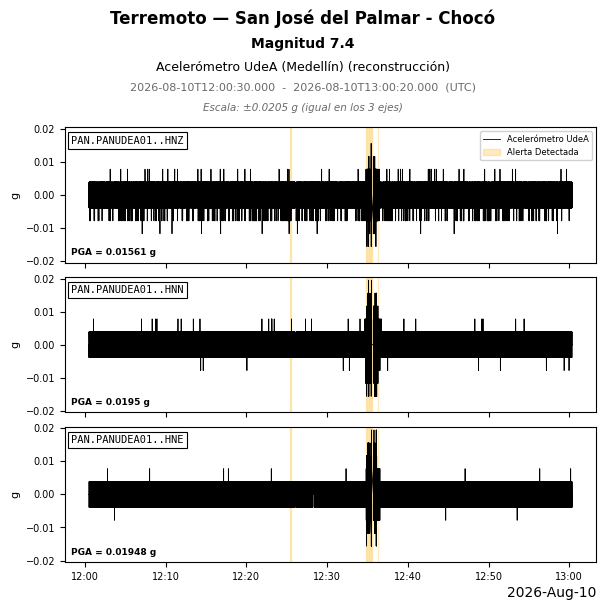

  guardado: output\plots\terremoto_choco_reconstruccion_hora_completa_g_UTC.png  (900x900 px)  [UTC]


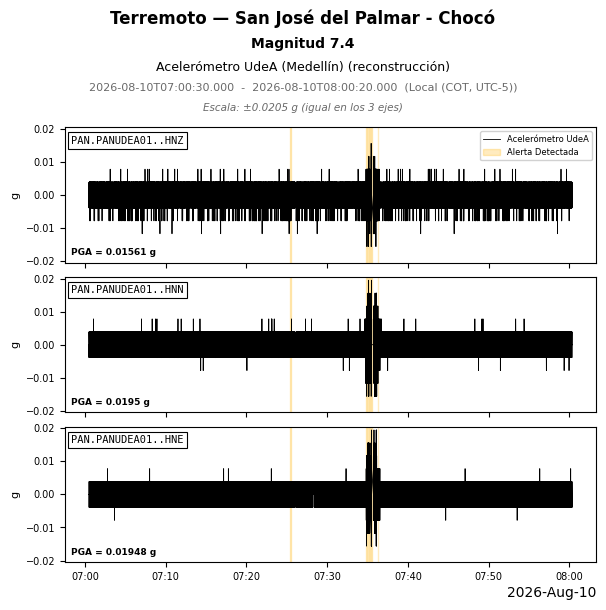

  guardado: output\plots\terremoto_choco_reconstruccion_hora_completa_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [10]:
plot_sgc_style(
    _series_propia(recon, "g"), unidad="g",
    save_path=DIR_OUT_PLOTS / "terremoto_choco_reconstruccion_hora_completa_g.png",
    estaciones=ESTACIONES_PROPIA + " (reconstrucción)",
    alert_windows=recon["alert_windows"],
)


### Reconstrucción -- cm/s²

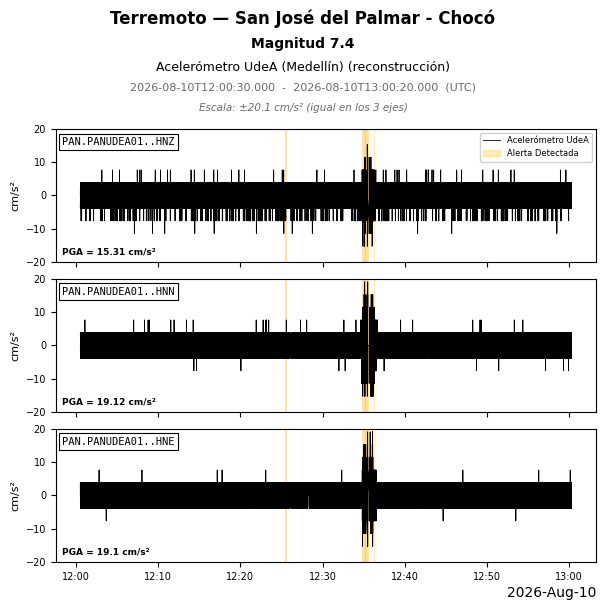

  guardado: output\plots\terremoto_choco_reconstruccion_hora_completa_cms2_UTC.png  (900x900 px)  [UTC]


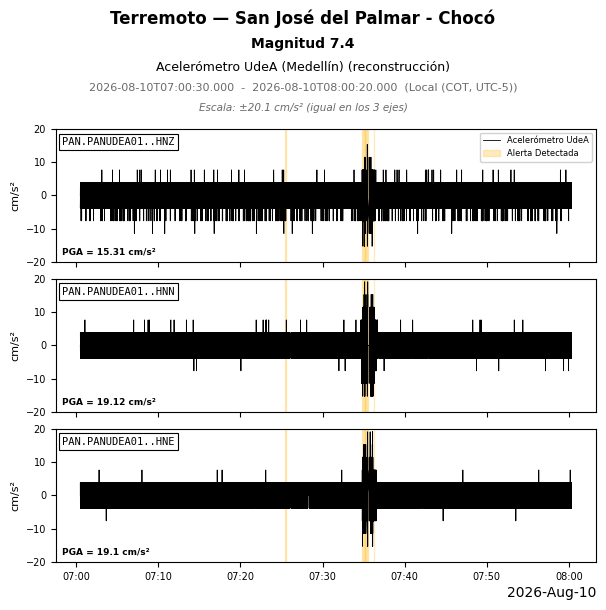

  guardado: output\plots\terremoto_choco_reconstruccion_hora_completa_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [11]:
plot_sgc_style(
    _series_propia(recon, "cm/s²"), unidad="cm/s²",
    save_path=DIR_OUT_PLOTS / "terremoto_choco_reconstruccion_hora_completa_cms2.png",
    estaciones=ESTACIONES_PROPIA + " (reconstrucción)",
    alert_windows=recon["alert_windows"],
)


## §8 — Ventana de comparación con Dabeiba

Se recorta la señal propia reconstruida a la ventana temporal real del
registro del SGC (510 s, iniciando en `INICIO_DABEIBA_UTC`).

In [12]:
t0_sgc = t_utc_sgc[0]
t1_sgc = t_utc_sgc[-1]

t_utc_propia = recon["t_utc"]
mask_ventana = (t_utc_propia >= t0_sgc) & (t_utc_propia <= t1_sgc)
if not mask_ventana.any():
    raise ValueError("La ventana del registro SGC no se solapa con la reconstrucción propia.")

t_utc_propia_rec  = t_utc_propia[mask_ventana]
data_g_propia_rec = recon["data_g"][mask_ventana]

print(f"Ventana de comparación: {t0_sgc} -> {t1_sgc}  UTC")
print(f"Muestras propias en la ventana: {mask_ventana.sum()}  /  muestras SGC: {len(t_utc_sgc)}")


Ventana de comparación: 2026-08-10T12:33:57.000000 -> 2026-08-10T12:42:27.000000  UTC
Muestras propias en la ventana: 102001  /  muestras SGC: 102001


## §9 — Gráficas de comparación con Dabeiba (separadas y juntas, g y cm/s²)

Se generan 6 figuras, cada una en su propia celda, en `data/Datos_SGC_Terremoto_Choco/`:
propia sola, SGC sola y ambas superpuestas, cada una en g y en cm/s². Las
versiones "solo propia" y "solo SGC" quedan en negro puro, igual que el
formato oficial del SGC; en las versiones superpuestas el SGC se dibuja en
rojo para distinguirlo. La versión conjunta deja ver el retraso de llegada de
la onda por la diferencia de distancia epicentral (UdeA más cerca del
epicentro que Dabeiba).

In [13]:
def _serie_unidad(t, data, codigo_base, nombre, color, unidad_datos, unidad_deseada):
    """`data` ya viene en `unidad_datos` ('g' o 'cm/s²'); se convierte si hace falta."""
    if unidad_datos == unidad_deseada:
        d = data
    elif unidad_datos == "g":
        d = data * G_TO_CMS2
    else:
        d = data / G_TO_CMS2
    return {comp: [(t, d[:, i], codigo_base, nombre, color)] for i, comp in enumerate(_LABELS)}


def _combinar(series_a, series_b):
    return {comp: series_a[comp] + series_b[comp] for comp in _LABELS}


print("_serie_unidad(), _combinar() definidas.")


_serie_unidad(), _combinar() definidas.


### Comparación -- g

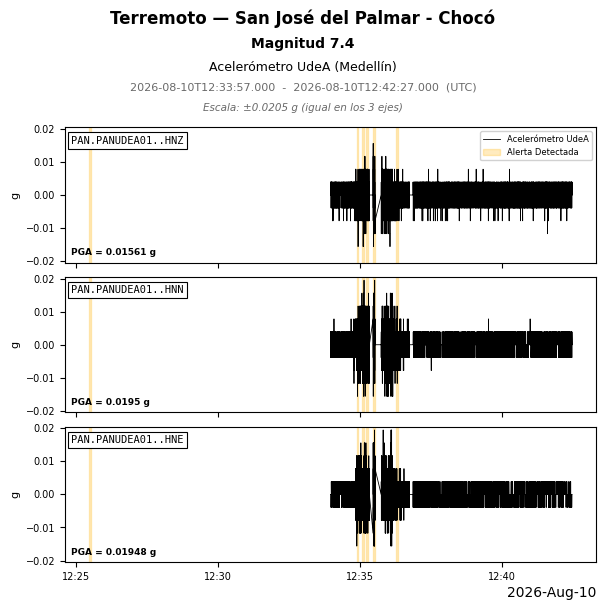

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_propia_g_UTC.png  (900x900 px)  [UTC]


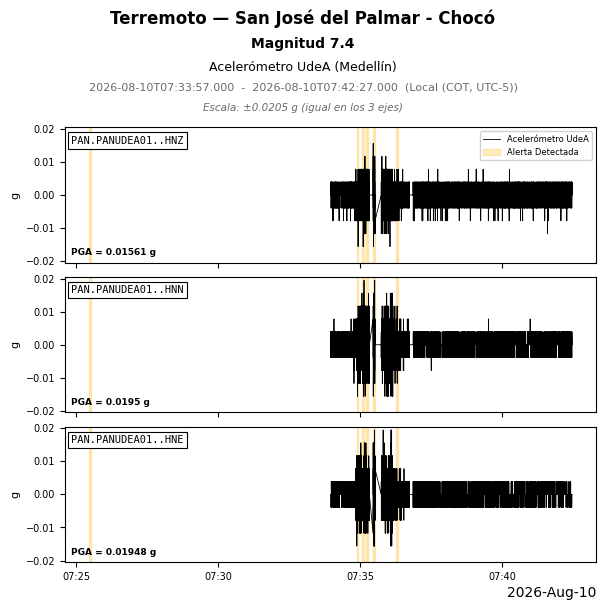

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_propia_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [14]:
serie_propia_g = _serie_unidad(t_utc_propia_rec, data_g_propia_rec, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")

plot_sgc_style(serie_propia_g, unidad="g",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_waveform_propia_g.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


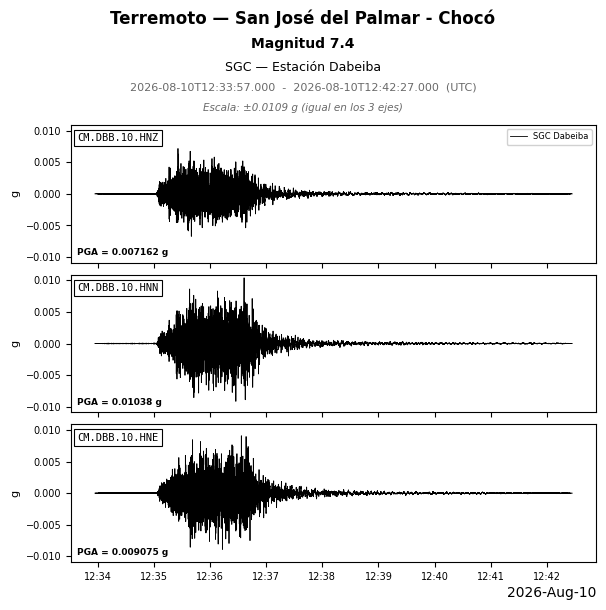

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_sgc_g_UTC.png  (900x900 px)  [UTC]


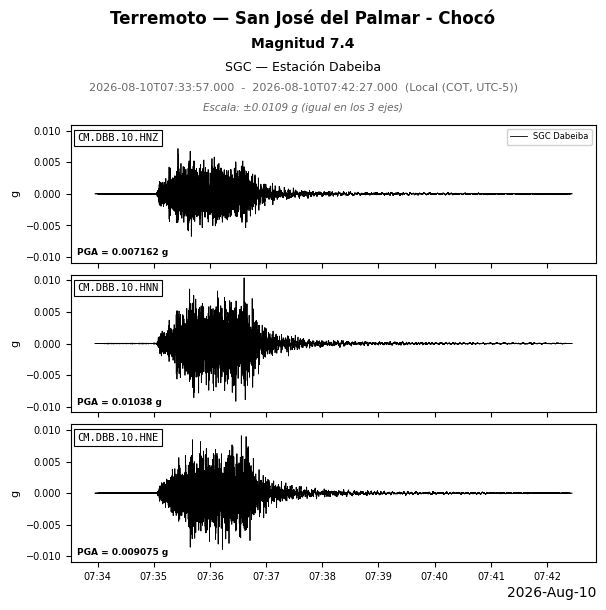

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_sgc_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [15]:
serie_sgc_g = _serie_unidad(t_utc_sgc, sgc_cms2, ID_SGC, "SGC Dabeiba", COLOR_PROPIA, "cm/s²", "g")

plot_sgc_style(serie_sgc_g, unidad="g",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_waveform_sgc_g.png",
               estaciones=ESTACIONES_SGC,
               alert_windows=None)


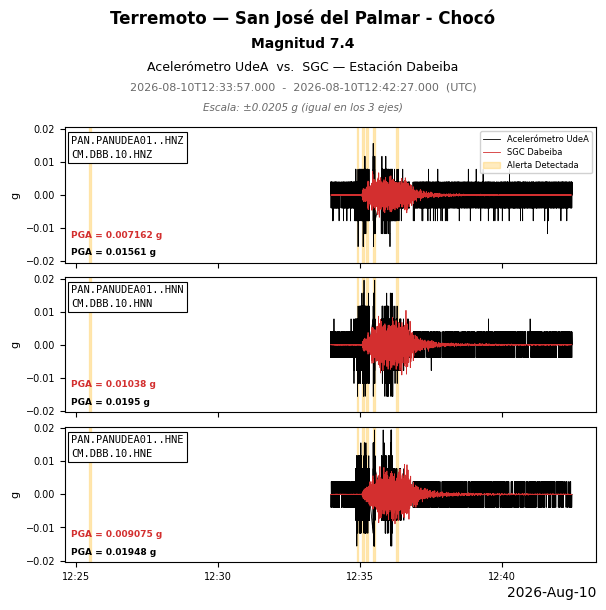

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_g_UTC.png  (900x900 px)  [UTC]


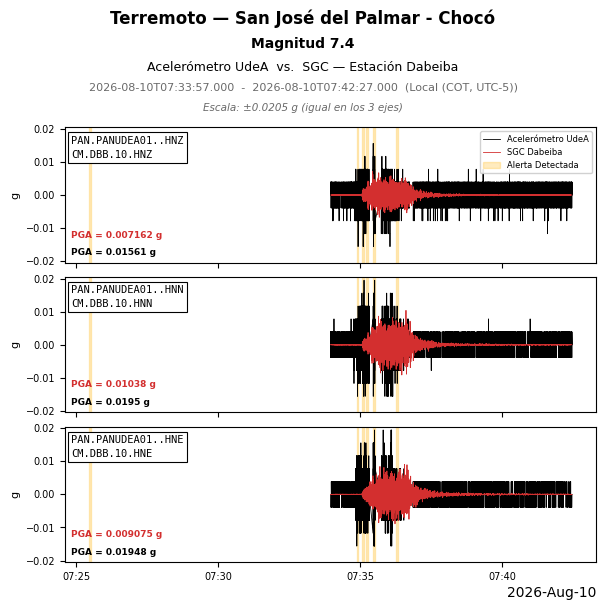

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [16]:
serie_sgc_g_rojo = _serie_unidad(t_utc_sgc, sgc_cms2, ID_SGC, "SGC Dabeiba", COLOR_SGC, "cm/s²", "g")
serie_junta_g = _combinar(serie_propia_g, serie_sgc_g_rojo)

plot_sgc_style(serie_junta_g, unidad="g",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_waveform_g.png",
               estaciones=ESTACIONES_AMBAS,
               alert_windows=recon["alert_windows"])


### Comparación -- cm/s²

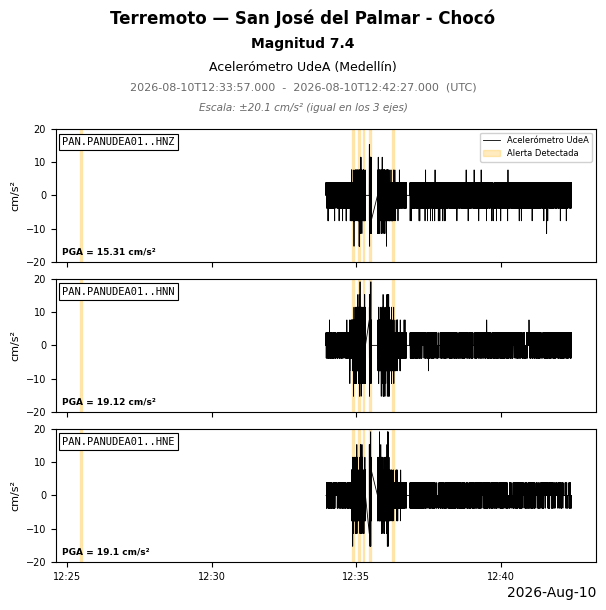

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_propia_cms2_UTC.png  (900x900 px)  [UTC]


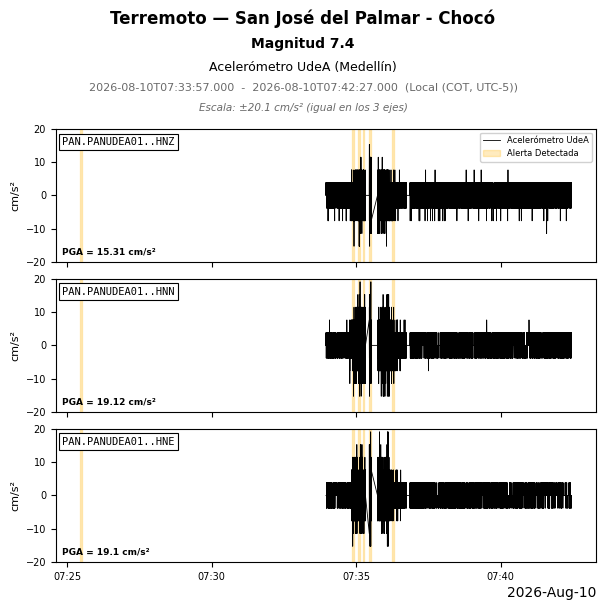

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_propia_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [17]:
serie_propia_cms2 = _serie_unidad(t_utc_propia_rec, data_g_propia_rec, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")

plot_sgc_style(serie_propia_cms2, unidad="cm/s²",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_waveform_propia_cms2.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


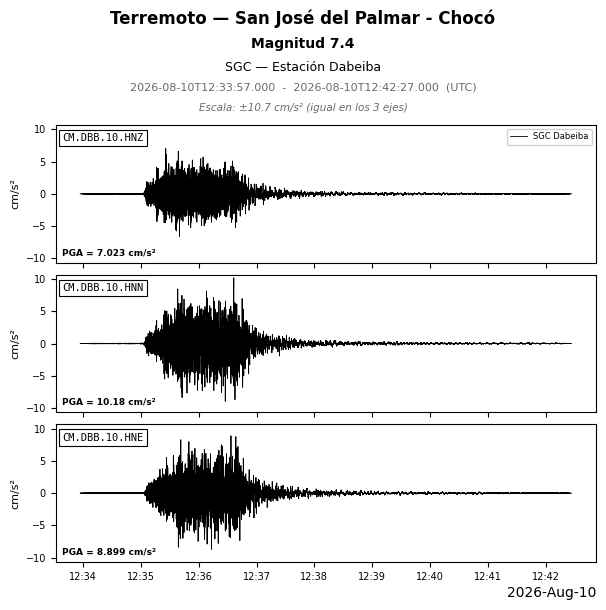

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_sgc_cms2_UTC.png  (900x900 px)  [UTC]


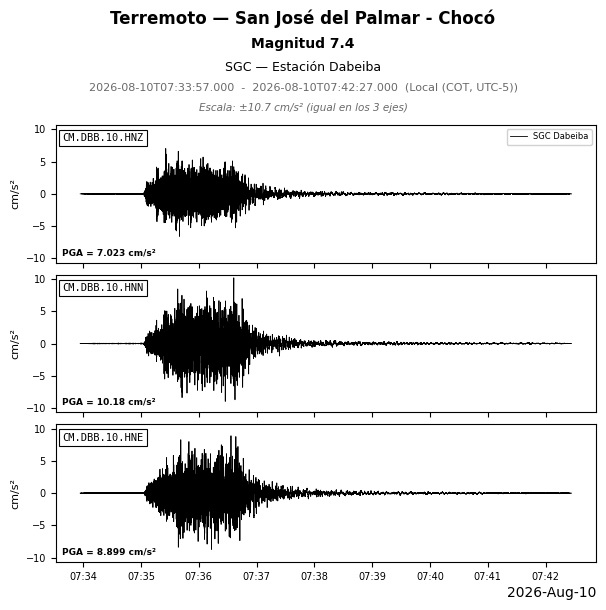

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_sgc_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [18]:
serie_sgc_cms2 = _serie_unidad(t_utc_sgc, sgc_cms2, ID_SGC, "SGC Dabeiba", COLOR_PROPIA, "cm/s²", "cm/s²")

plot_sgc_style(serie_sgc_cms2, unidad="cm/s²",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_waveform_sgc_cms2.png",
               estaciones=ESTACIONES_SGC,
               alert_windows=None)


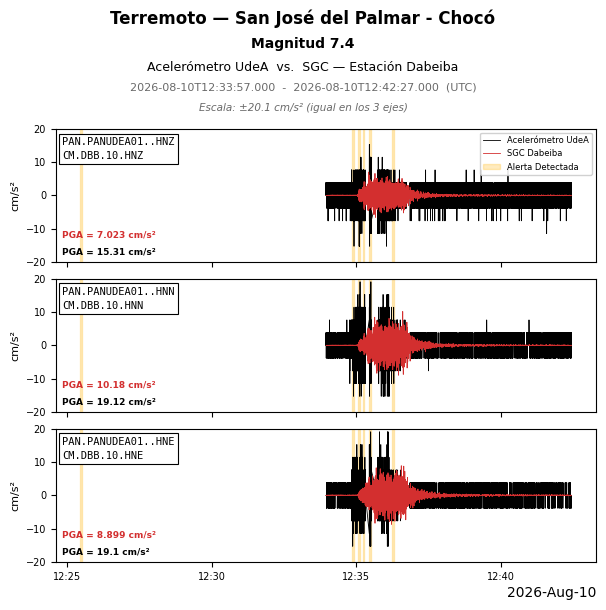

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_UTC.png  (900x900 px)  [UTC]


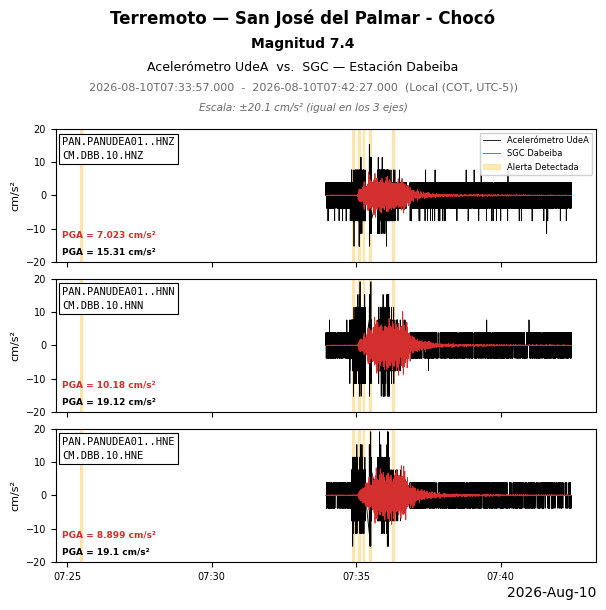

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [19]:
serie_sgc_cms2_rojo = _serie_unidad(t_utc_sgc, sgc_cms2, ID_SGC, "SGC Dabeiba", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_cms2 = _combinar(serie_propia_cms2, serie_sgc_cms2_rojo)

# Nombre exacto solicitado para esta figura (la principal de la comparación).
plot_sgc_style(serie_junta_cms2, unidad="cm/s²",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_waveform.png",
               estaciones=ESTACIONES_AMBAS,
               alert_windows=recon["alert_windows"])


## §10 — Gráfica nueva: comparación extendida (desde la primera alerta hasta el final del registro SGC)

En vez de recortar la señal propia a la ventana real del `.anc` del SGC, aquí
se extiende hacia atrás hasta el instante de la **primera alerta** detectada
por el acelerómetro propio (la del hueco de 25 s, antes del sismo principal),
y se mantiene hasta que termina el registro del SGC. El SGC solo tiene datos
dentro de su propia ventana de 510 s; antes/después de eso solo se ve la
traza propia.

In [20]:
t_inicio_ext = np.datetime64(recon["alert_windows"][0][0].replace(tzinfo=None))
t_fin_ext    = t_utc_sgc[-1]

mask_ext = (t_utc_propia >= t_inicio_ext) & (t_utc_propia <= t_fin_ext)
t_utc_propia_ext  = t_utc_propia[mask_ext]
data_g_propia_ext = recon["data_g"][mask_ext]

print(f"Ventana extendida: {t_inicio_ext} -> {t_fin_ext}  UTC  ({mask_ext.sum()} muestras propias)")


Ventana extendida: 2026-08-10T12:25:27.000000 -> 2026-08-10T12:42:27.000000  UTC  (204001 muestras propias)


### Comparación extendida -- g

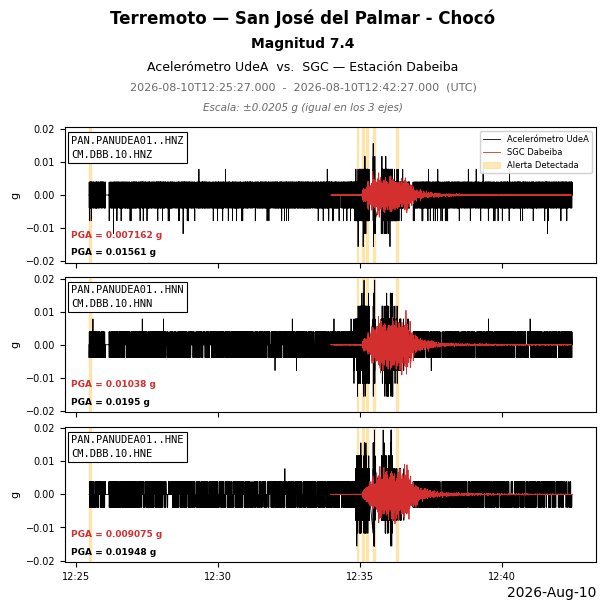

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_extendida_g_UTC.png  (900x900 px)  [UTC]


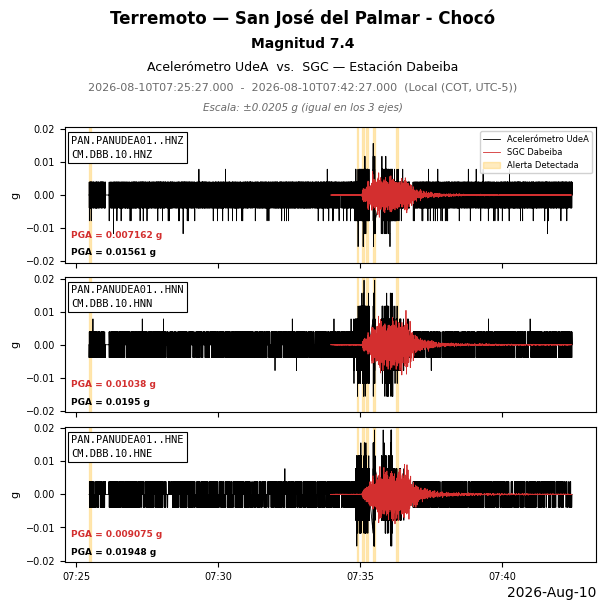

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_extendida_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [21]:
serie_propia_ext_g = _serie_unidad(t_utc_propia_ext, data_g_propia_ext, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")
serie_sgc_ext_g     = _serie_unidad(t_utc_sgc, sgc_cms2, ID_SGC, "SGC Dabeiba", COLOR_SGC, "cm/s²", "g")
serie_junta_ext_g   = _combinar(serie_propia_ext_g, serie_sgc_ext_g)

plot_sgc_style(serie_junta_ext_g, unidad="g",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_waveform_extendida_g.png",
               estaciones=ESTACIONES_AMBAS,
               alert_windows=recon["alert_windows"])


### Comparación extendida -- cm/s²

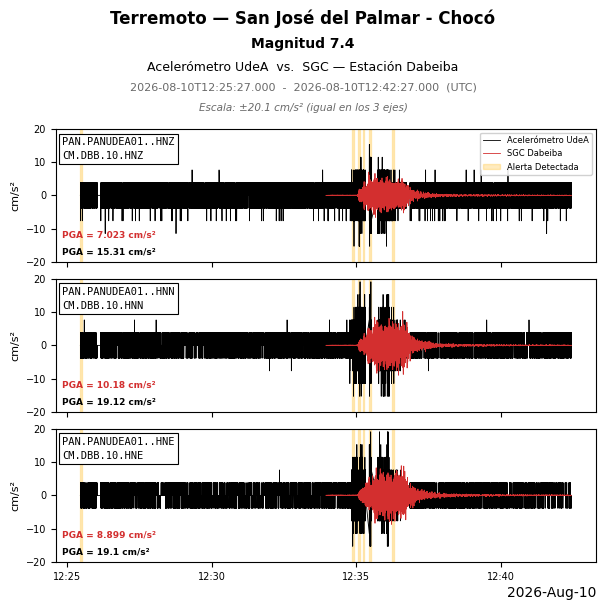

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_extendida_cms2_UTC.png  (900x900 px)  [UTC]


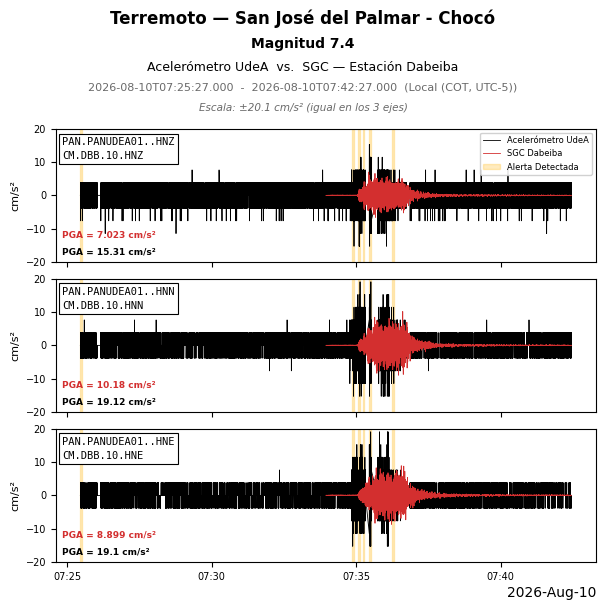

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_waveform_extendida_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [22]:
serie_propia_ext_cms2 = _serie_unidad(t_utc_propia_ext, data_g_propia_ext, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")
serie_sgc_ext_cms2     = _serie_unidad(t_utc_sgc, sgc_cms2, ID_SGC, "SGC Dabeiba", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_ext_cms2   = _combinar(serie_propia_ext_cms2, serie_sgc_ext_cms2)

plot_sgc_style(serie_junta_ext_cms2, unidad="cm/s²",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_waveform_extendida_cms2.png",
               estaciones=ESTACIONES_AMBAS,
               alert_windows=recon["alert_windows"])


## §11 — Comparación con una segunda estación del SGC: Pereira, Risaralda (CBOCA)

Mismo procedimiento que con Dabeiba (§5, §8, §9), pero para la estación CBOCA
del SGC en Pereira, Risaralda (mucho más cerca del epicentro: 75 km, frente a
226 km de Dabeiba). El registro real empieza en `INICIO_PEREIRA_UTC`
(`2026-08-10 12:33:57 UTC`, determinado por correlación cruzada contra el
`.mseed` -- ver §12).

In [23]:
header_pereira, pereira_cms2, pereira_g, t_utc_pereira, cols_pereira = parse_anc(RUTA_ANC_PEREIRA, INICIO_PEREIRA_UTC)

assert pereira_cms2.shape == (header_pereira["n_datos"], 3), "Número de filas/columnas inesperado en el .anc"

print("-- Cabecera SGC -- Estación Pereira (CBOCA) -------------------")
print(f"  Evento               : {header_pereira['descripcion_evento']}")
print(f"  Origen del sismo (UTC): {header_pereira['evento_datetime_utc']}  M={header_pereira['magnitud']}")
print(f"  Inicio del registro  : {t_utc_pereira[0]}  ->  fin: {t_utc_pereira[-1]}  UTC")
print(f"  Estación             : {header_pereira['codigo_estacion']}  lat={header_pereira['lat_estacion']}  lon={header_pereira['lon_estacion']}")
print(f"  Distancia epicentral : {header_pereira['distancia_epicentral']} km")
print(f"  Muestras             : {header_pereira['n_datos']}  ({header_pereira['sample_rate']} Hz, {header_pereira['duracion_s']} s)")
print(f"  Columnas en archivo  : {cols_pereira}")

ESTACIONES_PEREIRA = "SGC — Estación Pereira (CBOCA)"
ESTACIONES_AMBAS_PEREIRA = "Acelerómetro UdeA  vs.  SGC — Estación Pereira (CBOCA)"


-- Cabecera SGC -- Estación Pereira (CBOCA) -------------------
  Evento               : San Jos? del Palmar - Choc?, Colombia
  Origen del sismo (UTC): 2026-08-10 12:34:27+00:00  M=7.4
  Inicio del registro  : 2026-08-10T12:33:57.000000  ->  fin: 2026-08-10T12:42:27.000000  UTC
  Estación             : CBOCA  lat=4.7817  lon=-75.6455
  Distancia epicentral : 75.0 km
  Muestras             : 102001  (200 Hz, 510.0 s)
  Columnas en archivo  : ['EW', 'VER', 'NS']


### Ventana de comparación con Pereira

Se recorta la señal propia reconstruida a la ventana temporal real del
registro de Pereira (510 s, iniciando en `INICIO_PEREIRA_UTC`).

In [24]:
t0_pereira = t_utc_pereira[0]
t1_pereira = t_utc_pereira[-1]

mask_ventana_pereira = (t_utc_propia >= t0_pereira) & (t_utc_propia <= t1_pereira)
if not mask_ventana_pereira.any():
    raise ValueError("La ventana del registro de Pereira no se solapa con la reconstrucción propia.")

t_utc_propia_rec_pereira  = t_utc_propia[mask_ventana_pereira]
data_g_propia_rec_pereira = recon["data_g"][mask_ventana_pereira]

print(f"Ventana de comparación: {t0_pereira} -> {t1_pereira}  UTC")
print(f"Muestras propias en la ventana: {mask_ventana_pereira.sum()}  /  muestras SGC: {len(t_utc_pereira)}")


Ventana de comparación: 2026-08-10T12:33:57.000000 -> 2026-08-10T12:42:27.000000  UTC
Muestras propias en la ventana: 102001  /  muestras SGC: 102001


### Pereira -- g

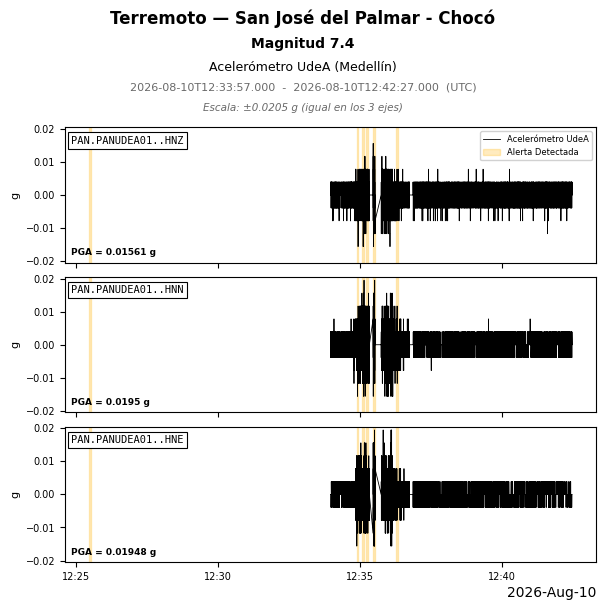

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_propia_g_UTC.png  (900x900 px)  [UTC]


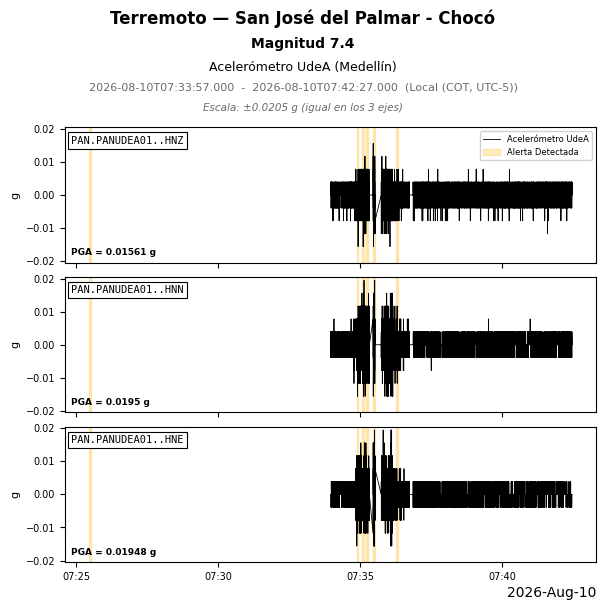

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_propia_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [25]:
serie_propia_pereira_g = _serie_unidad(t_utc_propia_rec_pereira, data_g_propia_rec_pereira, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")

plot_sgc_style(serie_propia_pereira_g, unidad="g",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_waveform_propia_g.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


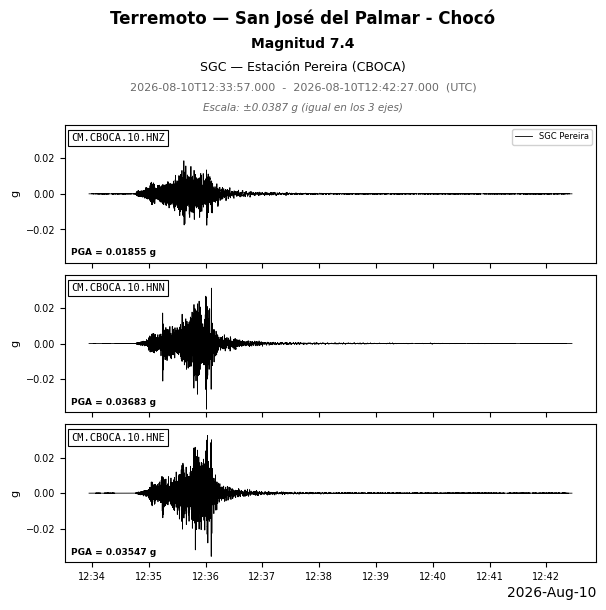

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_sgc_g_UTC.png  (900x900 px)  [UTC]


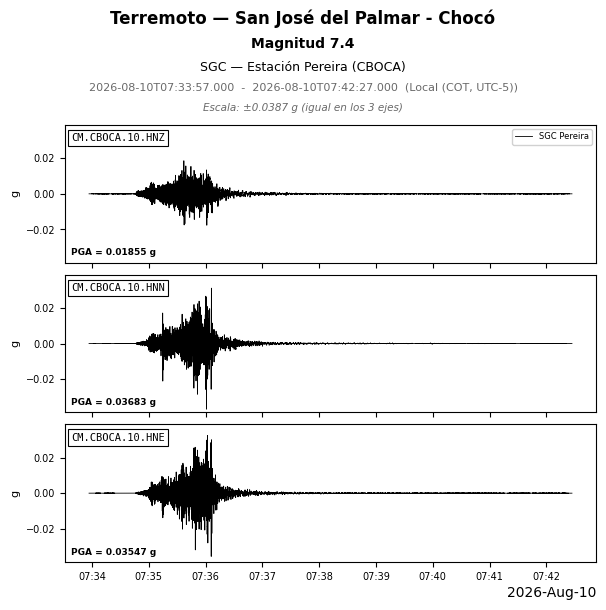

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_sgc_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [26]:
serie_sgc_pereira_g = _serie_unidad(t_utc_pereira, pereira_cms2, ID_PEREIRA, "SGC Pereira", COLOR_PROPIA, "cm/s²", "g")

plot_sgc_style(serie_sgc_pereira_g, unidad="g",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_waveform_sgc_g.png",
               estaciones=ESTACIONES_PEREIRA,
               alert_windows=None)


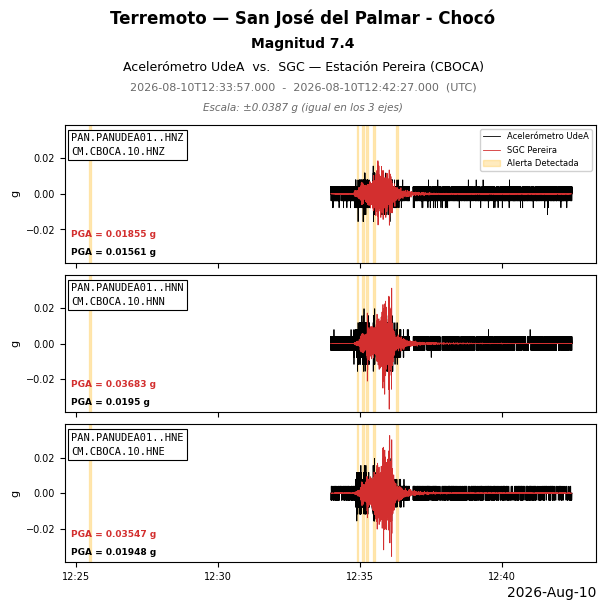

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_g_UTC.png  (900x900 px)  [UTC]


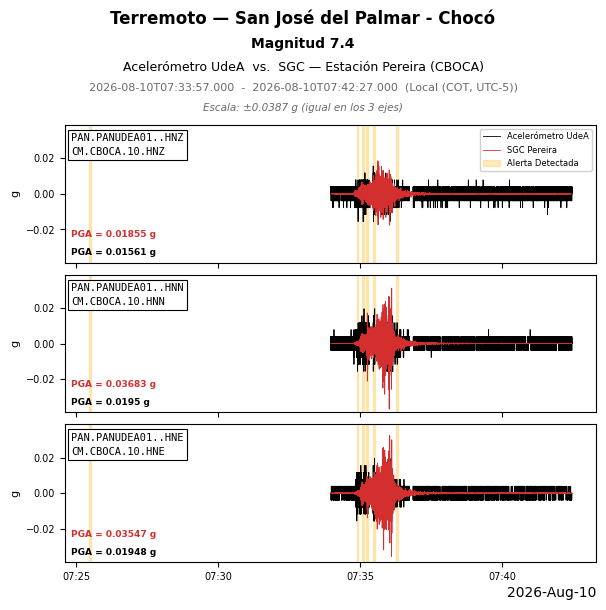

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [27]:
serie_sgc_pereira_g_rojo = _serie_unidad(t_utc_pereira, pereira_cms2, ID_PEREIRA, "SGC Pereira", COLOR_SGC, "cm/s²", "g")
serie_junta_pereira_g = _combinar(serie_propia_pereira_g, serie_sgc_pereira_g_rojo)

plot_sgc_style(serie_junta_pereira_g, unidad="g",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_waveform_g.png",
               estaciones=ESTACIONES_AMBAS_PEREIRA,
               alert_windows=recon["alert_windows"])


### Pereira -- cm/s²

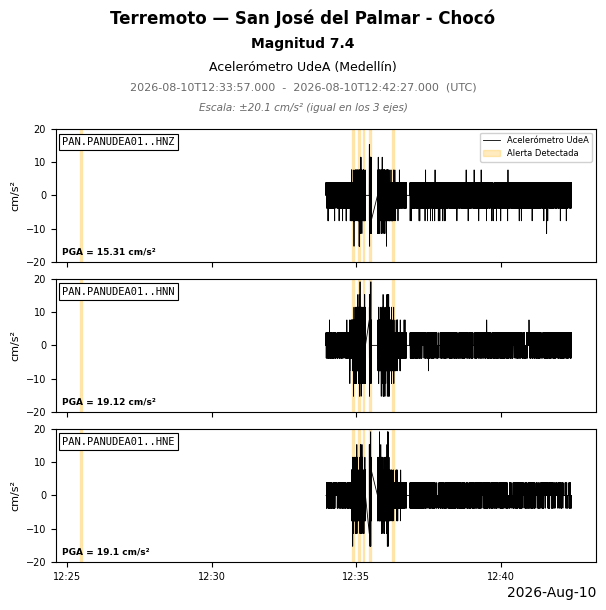

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_propia_cms2_UTC.png  (900x900 px)  [UTC]


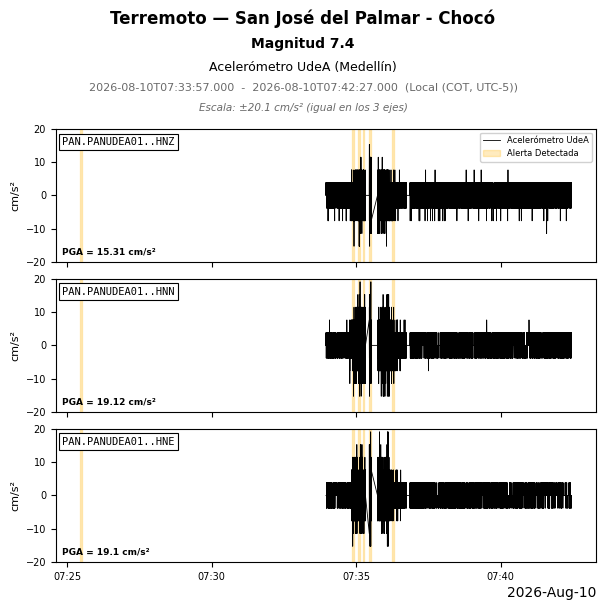

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_propia_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [28]:
serie_propia_pereira_cms2 = _serie_unidad(t_utc_propia_rec_pereira, data_g_propia_rec_pereira, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")

plot_sgc_style(serie_propia_pereira_cms2, unidad="cm/s²",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_waveform_propia_cms2.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


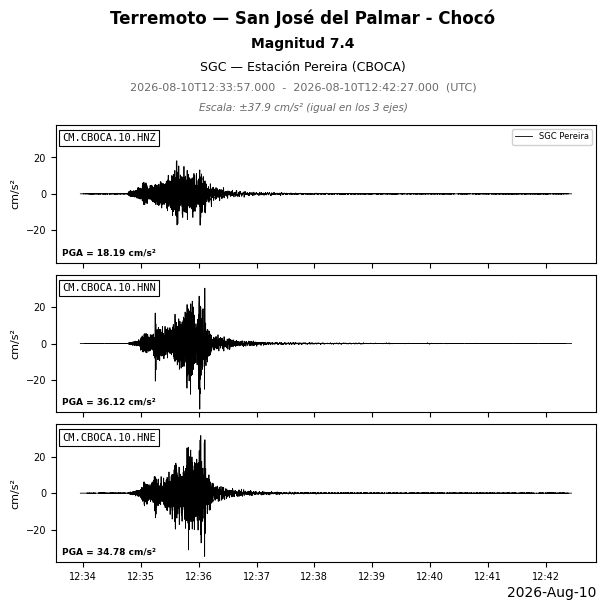

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_sgc_cms2_UTC.png  (900x900 px)  [UTC]


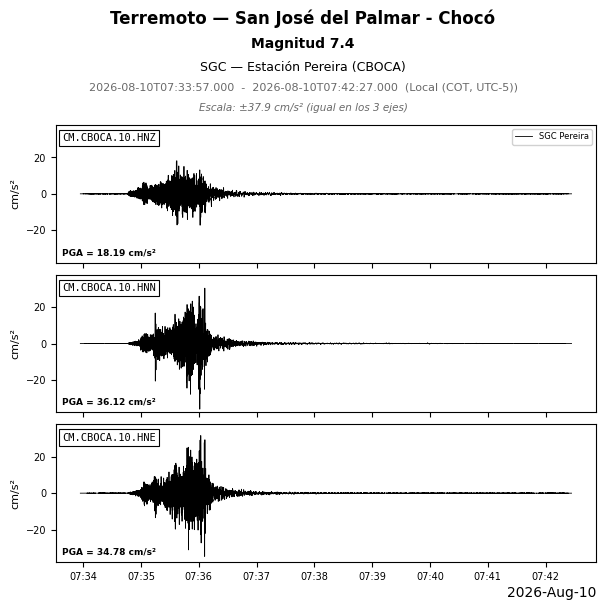

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_sgc_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [29]:
serie_sgc_pereira_cms2 = _serie_unidad(t_utc_pereira, pereira_cms2, ID_PEREIRA, "SGC Pereira", COLOR_PROPIA, "cm/s²", "cm/s²")

plot_sgc_style(serie_sgc_pereira_cms2, unidad="cm/s²",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_waveform_sgc_cms2.png",
               estaciones=ESTACIONES_PEREIRA,
               alert_windows=None)


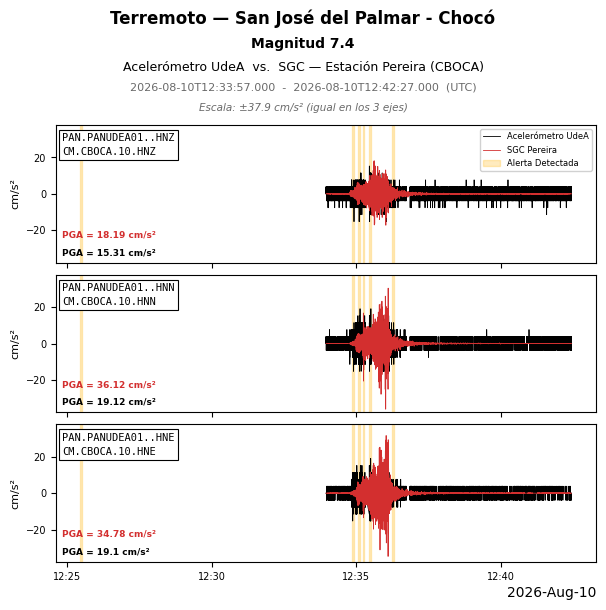

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_UTC.png  (900x900 px)  [UTC]


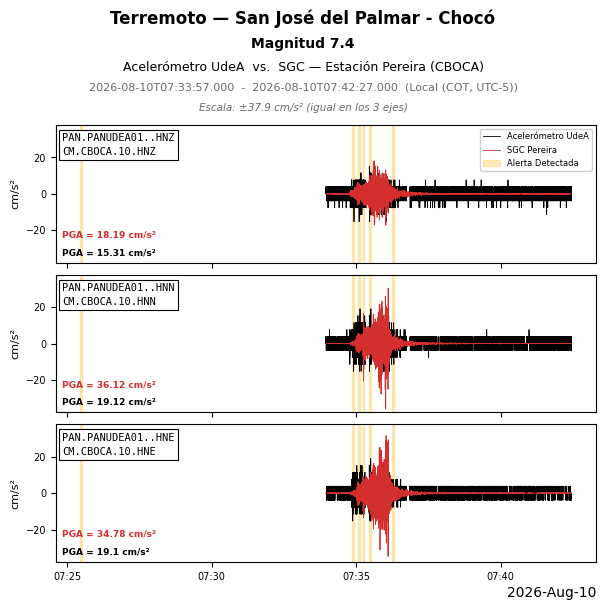

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_waveform_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [30]:
serie_sgc_pereira_cms2_rojo = _serie_unidad(t_utc_pereira, pereira_cms2, ID_PEREIRA, "SGC Pereira", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_pereira_cms2 = _combinar(serie_propia_pereira_cms2, serie_sgc_pereira_cms2_rojo)

plot_sgc_style(serie_junta_pereira_cms2, unidad="cm/s²",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_waveform.png",
               estaciones=ESTACIONES_AMBAS_PEREIRA,
               alert_windows=recon["alert_windows"])


## §12 — Pereira (CBOCA) a partir de los `.mseed` crudos

El usuario descargó 3 archivos `.mseed` de la estación CBOCA (uno por canal,
`CM.CBOCA.10.HN{E,N,Z}`), con una ventana mucho más ancha que el `.anc`
(~2026-08-10T12:25:25 -- 12:45:05 UTC, ~19.7 min, frente a los 510 s del
`.anc`). A diferencia del `.anc`, el `.mseed` **sí** trae una hora de inicio
exacta en su propia cabecera -- pero sus valores son **cuentas crudas del
digitalizador** (enteros de cientos de miles, sin remover línea base), no
cm/s², porque el archivo no incluye la respuesta del instrumento.

**Calibración**: como no hay archivo de respuesta (RESP/StationXML), se
determina el factor cuentas → cm/s² por **correlación cruzada** contra el
`.anc` ya calibrado de la misma estación/canal (ambos deberían registrar la
misma señal física). Esto de paso revela el desfase de tiempo real entre
ambos archivos.

> **Hallazgo importante**: la correlación cruzada (R² > 0.999 en los 3
> canales, resultado consistente e independiente por canal) reveló que la
> hora de inicio real del `.anc` de Pereira es **2026-08-10T12:33:57 UTC**
> (30 s antes del origen del sismo). El mismo patrón se confirmó también en
> Dabeiba y Riosucio (9 canales en total), así que `INICIO_PEREIRA_UTC` (§2)
> ya usa este valor corregido en §11.

In [31]:
from obspy import read as obspy_read

RUTA_MSEED_PEREIRA = {
    "HNE": pathlib.Path("data/Datos_SGC_Terremoto_Choco/CBOCA_HNE.mseed"),
    "HNN": pathlib.Path("data/Datos_SGC_Terremoto_Choco/CBOCA_HNN.mseed"),
    "HNZ": pathlib.Path("data/Datos_SGC_Terremoto_Choco/CBOCA_HNZ.mseed"),
}

trazas_mseed = {}
print("-- Trazas .mseed crudas -- Pereira (CBOCA) --------------------")
for canal, ruta in RUTA_MSEED_PEREIRA.items():
    tr = obspy_read(str(ruta))[0]
    trazas_mseed[canal] = tr
    print(f"  {canal}: {tr.id}  {tr.stats.starttime} -> {tr.stats.endtime}  "
          f"{tr.stats.sampling_rate} Hz  {tr.stats.npts} muestras  "
          f"(cuentas: min={tr.data.min()}, max={tr.data.max()})")


-- Trazas .mseed crudas -- Pereira (CBOCA) --------------------


  HNE: CM.CBOCA.10.HNE  2026-08-10T12:25:25.305000Z -> 2026-08-10T12:45:04.790000Z  200.0 Hz  235898 muestras  (cuentas: min=-253850, max=28331)
  HNN: CM.CBOCA.10.HNN  2026-08-10T12:25:25.660000Z -> 2026-08-10T12:45:04.970000Z  200.0 Hz  235863 muestras  (cuentas: min=340971, max=623370)
  HNZ: CM.CBOCA.10.HNZ  2026-08-10T12:25:25.180000Z -> 2026-08-10T12:45:05.340000Z  200.0 Hz  236033 muestras  (cuentas: min=259497, max=410035)


### Calibración por correlación cruzada contra el `.anc`

In [32]:
from scipy.signal import correlate, correlation_lags


def calibrar_canal_mseed(tr, señal_anc_cms2, dt_anc):
    """
    Determina el factor de escala cuentas -> cm/s² de un canal .mseed sin
    calibrar, por correlación cruzada contra la señal ya calibrada del mismo
    canal en el .anc (que debería registrar la misma señal física). También
    revela el desfase de tiempo real entre ambos archivos.
    """
    x_counts = tr.data.astype(np.float64)
    x_counts = x_counts - np.median(x_counts)  # quita el offset DC del digitalizador
    y = señal_anc_cms2.astype(np.float64)
    n = len(y)

    xn = x_counts / (np.std(x_counts) + 1e-9)
    yn = y / (np.std(y) + 1e-9)
    corr = correlate(yn, xn, mode="full", method="fft")
    lags = correlation_lags(len(yn), len(xn), mode="full")
    lag = int(lags[np.argmax(np.abs(corr))])

    # y[n] = x[n - lag]  =>  inicio real del .anc = inicio del .mseed - lag*dt
    inicio_anc_implicito = tr.stats.starttime.datetime.replace(tzinfo=timezone.utc) - timedelta(seconds=lag * dt_anc)

    inicio_idx = -lag
    x_alineado = x_counts[inicio_idx: inicio_idx + n]
    A = np.vstack([x_alineado, np.ones_like(x_alineado)]).T
    escala, offset = np.linalg.lstsq(A, y, rcond=None)[0]
    r2 = 1 - np.var(y - (escala * x_alineado + offset)) / np.var(y)

    return {"lag": lag, "escala": escala, "offset": offset, "r2": r2, "inicio_anc_implicito": inicio_anc_implicito}


print("Calibrando canales .mseed de Pereira contra el .anc (misma estación)...")
calibracion_mseed = {}
for i, canal in enumerate(["HNE", "HNN", "HNZ"]):
    resultado = calibrar_canal_mseed(trazas_mseed[canal], pereira_cms2[:, i], header_pereira["sample_dt"])
    calibracion_mseed[canal] = resultado
    print(f"  {canal}: escala={resultado['escala']:.4e} cm/s²/cuenta  R²={resultado['r2']:.5f}  "
          f"inicio real implícito del .anc: {resultado['inicio_anc_implicito']}")


Calibrando canales .mseed de Pereira contra el .anc (misma estación)...
  HNE: escala=2.3564e-04 cm/s²/cuenta  R²=0.99992  inicio real implícito del .anc: 2026-08-10 12:33:57+00:00
  HNN: escala=2.3564e-04 cm/s²/cuenta  R²=0.99992  inicio real implícito del .anc: 2026-08-10 12:33:57+00:00
  HNZ: escala=2.3561e-04 cm/s²/cuenta  R²=0.99981  inicio real implícito del .anc: 2026-08-10 12:33:57+00:00


### Aplicar calibración y alinear los 3 canales

In [33]:
# -- Aplica la calibración: cuentas -> cm/s² (usa la hora de inicio propia de
#    cada canal .mseed, que sí es exacta -- no depende de la hora del .anc) --
señales_cal_cms2, t_por_canal = {}, {}
for canal in ["HNE", "HNN", "HNZ"]:
    tr = trazas_mseed[canal]
    c = calibracion_mseed[canal]
    x = tr.data.astype(np.float64) - np.median(tr.data.astype(np.float64))
    señales_cal_cms2[canal] = x * c["escala"]
    t0 = np.datetime64(tr.stats.starttime.datetime)
    dt_mseed = 1.0 / tr.stats.sampling_rate
    t_por_canal[canal] = t0 + (np.arange(tr.stats.npts) * dt_mseed * 1e6).astype("int64").astype("timedelta64[us]")

# -- Los 3 canales no arrancan exactamente en el mismo instante ni tienen el
#    mismo número de muestras -- se recortan a su ventana común --
t_inicio_comun = max(t_por_canal[c][0] for c in t_por_canal)
t_fin_comun    = min(t_por_canal[c][-1] for c in t_por_canal)

mseed_cms2 = np.column_stack([
    señales_cal_cms2[canal][(t_por_canal[canal] >= t_inicio_comun) & (t_por_canal[canal] <= t_fin_comun)]
    for canal in ["HNE", "HNN", "HNZ"]
])
t_utc_mseed = t_por_canal["HNE"][(t_por_canal["HNE"] >= t_inicio_comun) & (t_por_canal["HNE"] <= t_fin_comun)]

n_comun = min(mseed_cms2.shape[0], len(t_utc_mseed))
mseed_cms2  = mseed_cms2[:n_comun]
t_utc_mseed = t_utc_mseed[:n_comun]
mseed_g     = mseed_cms2 / G_TO_CMS2

print(f"Ventana común de los 3 canales: {t_utc_mseed[0]} -> {t_utc_mseed[-1]}  UTC  "
      f"({n_comun} muestras, {n_comun/200:.1f} s)")

ID_PEREIRA_MSEED = ID_PEREIRA  # mismo NSLC (CM.CBOCA.10) -- confirmado en la cabecera del .mseed
ESTACIONES_PEREIRA_MSEED = "SGC — Estación Pereira (CBOCA, miniSEED)"
ESTACIONES_AMBAS_PEREIRA_MSEED = "Acelerómetro UdeA  vs.  SGC — Estación Pereira (CBOCA, miniSEED)"


Ventana común de los 3 canales: 2026-08-10T12:25:25.660000 -> 2026-08-10T12:45:04.790000  UTC  (235827 muestras, 1179.1 s)


### Ventana de comparación (mseed)

Se recorta la señal propia reconstruida a la ventana común de los 3 canales
`.mseed` (mucho más ancha que la del `.anc`: ~19.7 min en vez de 510 s).

In [34]:
mask_ventana_mseed = (t_utc_propia >= t_utc_mseed[0]) & (t_utc_propia <= t_utc_mseed[-1])
if not mask_ventana_mseed.any():
    raise ValueError("La ventana del .mseed no se solapa con la reconstrucción propia.")

t_utc_propia_rec_mseed  = t_utc_propia[mask_ventana_mseed]
data_g_propia_rec_mseed = recon["data_g"][mask_ventana_mseed]

print(f"Ventana de comparación: {t_utc_mseed[0]} -> {t_utc_mseed[-1]}  UTC")
print(f"Muestras propias en la ventana: {mask_ventana_mseed.sum()}  /  muestras mseed: {n_comun}")


Ventana de comparación: 2026-08-10T12:25:25.660000 -> 2026-08-10T12:45:04.790000  UTC
Muestras propias en la ventana: 235827  /  muestras mseed: 235827


### Pereira (mseed) -- g

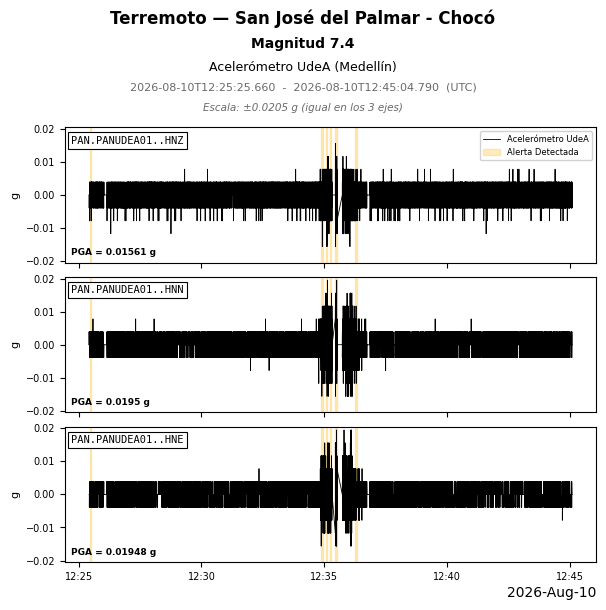

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_propia_g_UTC.png  (900x900 px)  [UTC]


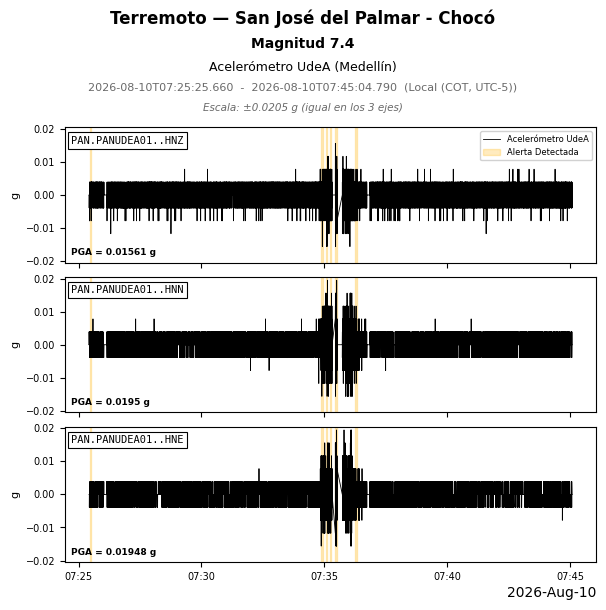

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_propia_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [35]:
serie_propia_mseed_g = _serie_unidad(t_utc_propia_rec_mseed, data_g_propia_rec_mseed, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")

plot_sgc_style(serie_propia_mseed_g, unidad="g",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_mseed_waveform_propia_g.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


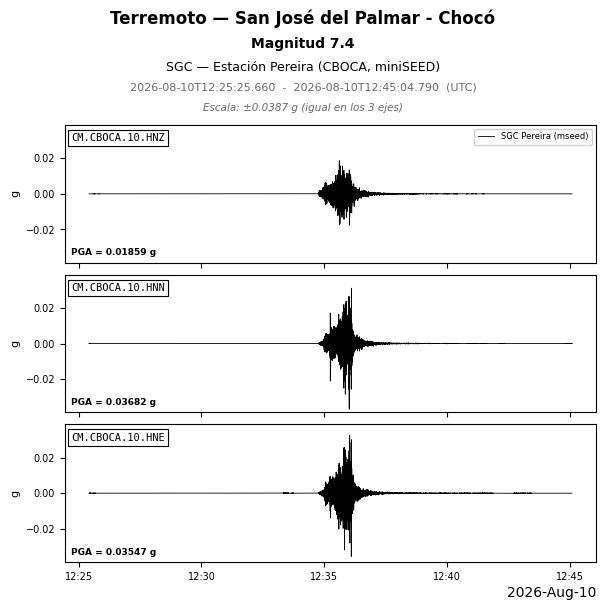

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_sgc_g_UTC.png  (900x900 px)  [UTC]


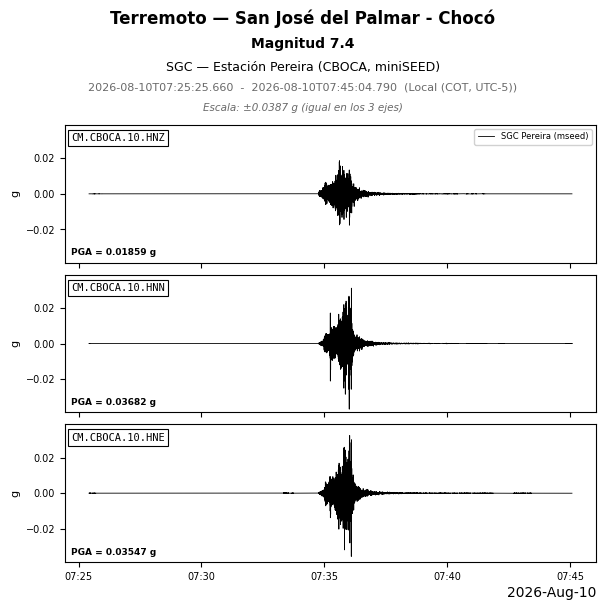

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_sgc_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [36]:
serie_sgc_mseed_g = _serie_unidad(t_utc_mseed, mseed_cms2, ID_PEREIRA_MSEED, "SGC Pereira (mseed)", COLOR_PROPIA, "cm/s²", "g")

plot_sgc_style(serie_sgc_mseed_g, unidad="g",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_mseed_waveform_sgc_g.png",
               estaciones=ESTACIONES_PEREIRA_MSEED,
               alert_windows=None)


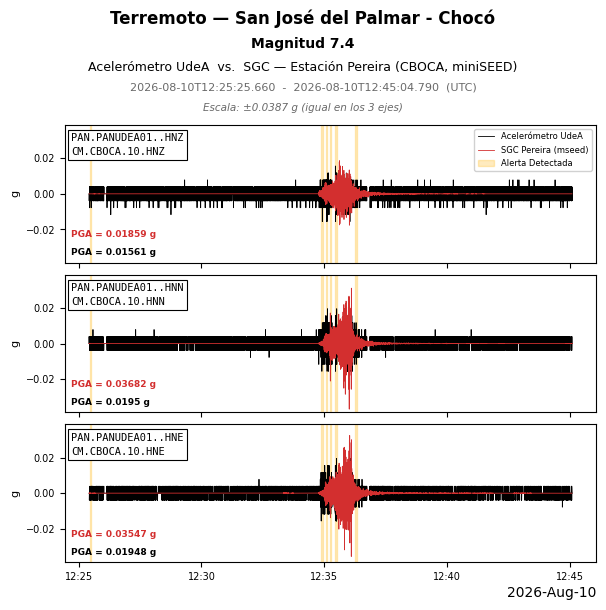

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_g_UTC.png  (900x900 px)  [UTC]


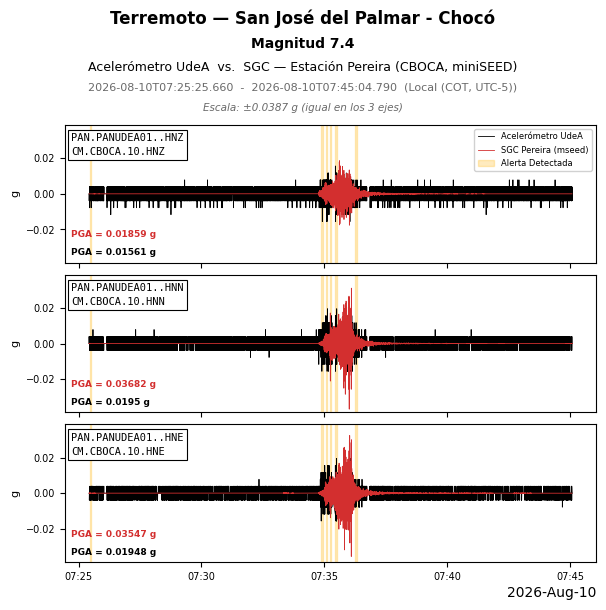

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [37]:
serie_sgc_mseed_g_rojo = _serie_unidad(t_utc_mseed, mseed_cms2, ID_PEREIRA_MSEED, "SGC Pereira (mseed)", COLOR_SGC, "cm/s²", "g")
serie_junta_mseed_g = _combinar(serie_propia_mseed_g, serie_sgc_mseed_g_rojo)

plot_sgc_style(serie_junta_mseed_g, unidad="g",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_mseed_waveform_g.png",
               estaciones=ESTACIONES_AMBAS_PEREIRA_MSEED,
               alert_windows=recon["alert_windows"])


### Pereira (mseed) -- cm/s²

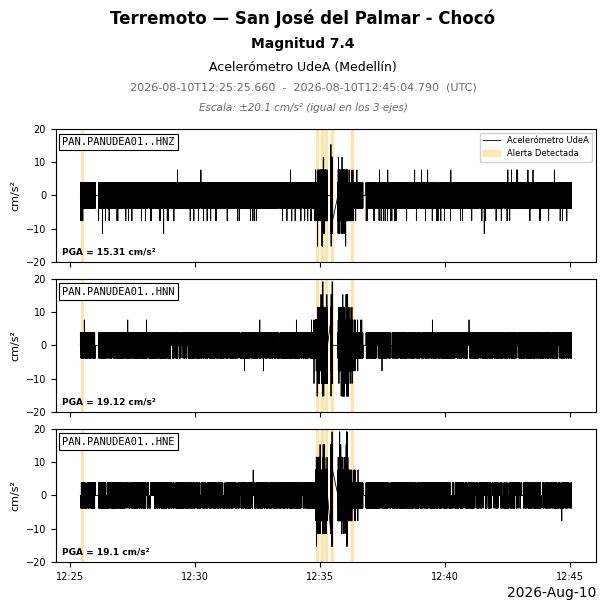

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_propia_cms2_UTC.png  (900x900 px)  [UTC]


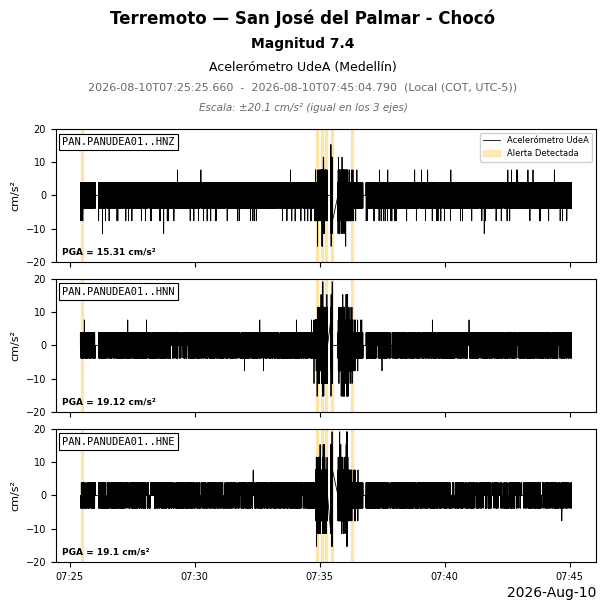

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_propia_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [38]:
serie_propia_mseed_cms2 = _serie_unidad(t_utc_propia_rec_mseed, data_g_propia_rec_mseed, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")

plot_sgc_style(serie_propia_mseed_cms2, unidad="cm/s²",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_mseed_waveform_propia_cms2.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


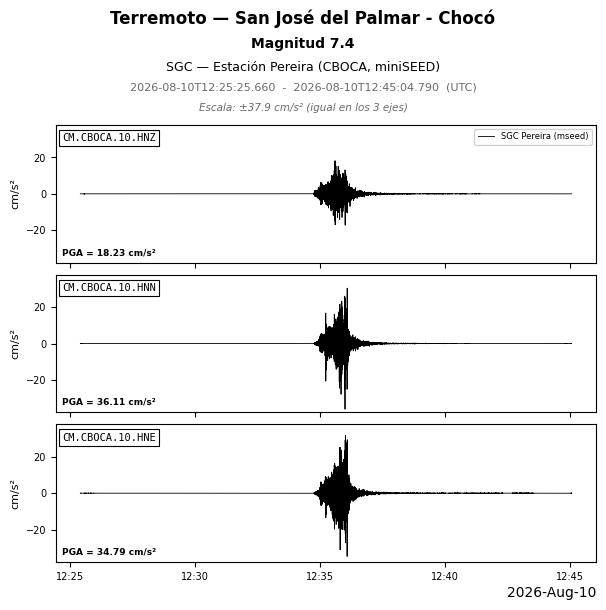

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_sgc_cms2_UTC.png  (900x900 px)  [UTC]


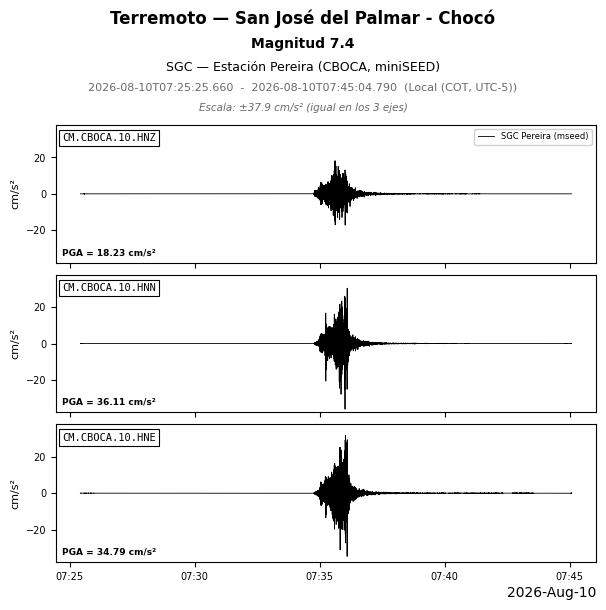

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_sgc_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [39]:
serie_sgc_mseed_cms2 = _serie_unidad(t_utc_mseed, mseed_cms2, ID_PEREIRA_MSEED, "SGC Pereira (mseed)", COLOR_PROPIA, "cm/s²", "cm/s²")

plot_sgc_style(serie_sgc_mseed_cms2, unidad="cm/s²",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_mseed_waveform_sgc_cms2.png",
               estaciones=ESTACIONES_PEREIRA_MSEED,
               alert_windows=None)


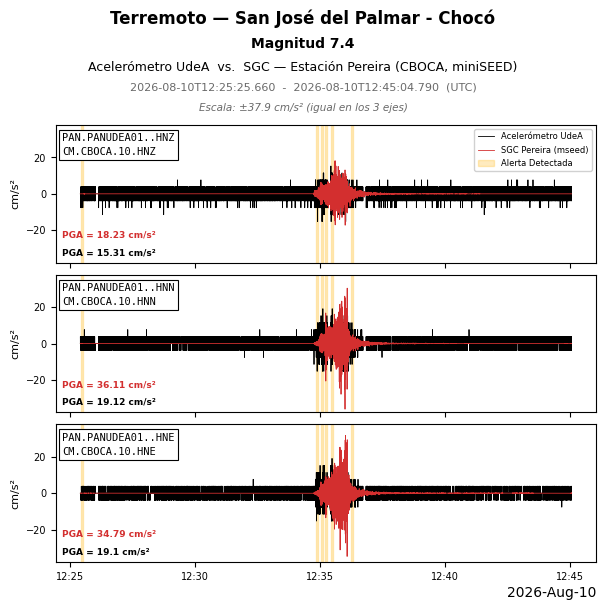

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_UTC.png  (900x900 px)  [UTC]


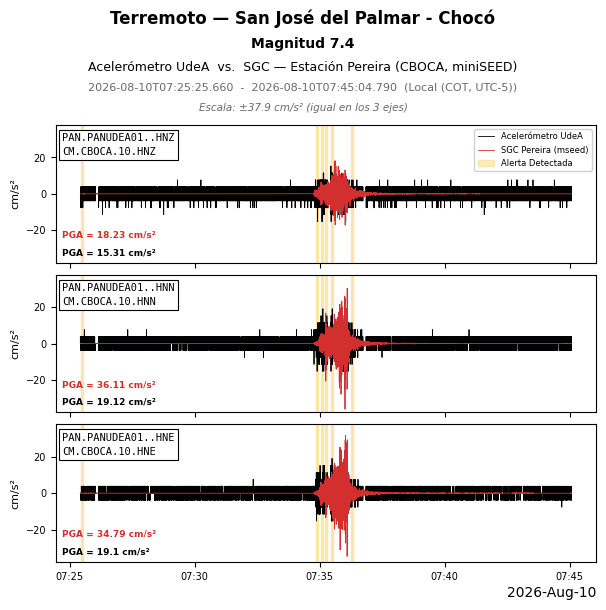

  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [40]:
serie_sgc_mseed_cms2_rojo = _serie_unidad(t_utc_mseed, mseed_cms2, ID_PEREIRA_MSEED, "SGC Pereira (mseed)", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_mseed_cms2 = _combinar(serie_propia_mseed_cms2, serie_sgc_mseed_cms2_rojo)

plot_sgc_style(serie_junta_mseed_cms2, unidad="cm/s²",
               save_path=DIR_PEREIRA / "pereira_CBOCA_10_mseed_waveform.png",
               estaciones=ESTACIONES_AMBAS_PEREIRA_MSEED,
               alert_windows=recon["alert_windows"])


## §13 — Dabeiba (DBB) a partir del `.mseed` crudo

El usuario descargó un solo archivo `DBB.mseed` con **9 trazas** (3 tipos de
sensor × 3 componentes): `CM.DBB.20.EH*` (100 Hz), `CM.DBB.10.HN*` (200 Hz) y
`CM.DBB.00.HH*` (100 Hz). Se usan únicamente los canales **`CM.DBB.10.HN*`**
-- los mismos que ya veníamos usando para Dabeiba (coinciden exactamente con
el NSLC del `.anc`, `ID_SGC = "CM.DBB.10"`), ignorando los otros dos grupos
de sensores. Mismo procedimiento que con Pereira en §12: los valores son
cuentas crudas del digitalizador (sin calibrar), así que se calibran por
correlación cruzada contra el `.anc` ya calibrado de Dabeiba, reutilizando
`calibrar_canal_mseed()` definida en §12.

In [41]:
st_dbb_completo = obspy_read(str(RUTA_MSEED_DABEIBA_TODO))
st_dbb_hn = st_dbb_completo.select(location="10", channel="HN*")

trazas_mseed_dabeiba = {}
print("-- Trazas .mseed crudas -- Dabeiba (CM.DBB.10.HN*) --------------------")
for tr in st_dbb_hn:
    canal = tr.stats.channel[-1]  # "HNE" -> "E", etc. -- se usa como llave "HNE"/"HNN"/"HNZ" abajo
    canal_key = tr.stats.channel
    trazas_mseed_dabeiba[canal_key] = tr
    print(f"  {canal_key}: {tr.id}  {tr.stats.starttime} -> {tr.stats.endtime}  "
          f"{tr.stats.sampling_rate} Hz  {tr.stats.npts} muestras  "
          f"(cuentas: min={tr.data.min()}, max={tr.data.max()})")


-- Trazas .mseed crudas -- Dabeiba (CM.DBB.10.HN*) --------------------
  HNE: CM.DBB.10.HNE  2026-08-10T12:25:26.520000Z -> 2026-08-10T12:45:06.590000Z  200.0 Hz  236015 muestras  (cuentas: min=-63461, max=-7754)
  HNN: CM.DBB.10.HNN  2026-08-10T12:25:24.710000Z -> 2026-08-10T12:45:05.685000Z  200.0 Hz  236196 muestras  (cuentas: min=-70260, max=-9341)
  HNZ: CM.DBB.10.HNZ  2026-08-10T12:25:23.875000Z -> 2026-08-10T12:45:07.355000Z  200.0 Hz  236697 muestras  (cuentas: min=-55042, max=-11551)


### Calibración por correlación cruzada contra el `.anc` de Dabeiba

In [42]:
print("Calibrando canales .mseed de Dabeiba contra el .anc (misma estación)...")
calibracion_mseed_dabeiba = {}
for i, canal in enumerate(["HNE", "HNN", "HNZ"]):
    resultado = calibrar_canal_mseed(trazas_mseed_dabeiba[canal], sgc_cms2[:, i], header_sgc["sample_dt"])
    calibracion_mseed_dabeiba[canal] = resultado
    print(f"  {canal}: escala={resultado['escala']:.4e} cm/s²/cuenta  R²={resultado['r2']:.5f}  "
          f"inicio real implícito del .anc: {resultado['inicio_anc_implicito']}")


Calibrando canales .mseed de Dabeiba contra el .anc (misma estación)...
  HNE: escala=3.1506e-04 cm/s²/cuenta  R²=0.99677  inicio real implícito del .anc: 2026-08-10 12:33:57.005000+00:00
  HNN: escala=3.1406e-04 cm/s²/cuenta  R²=0.99662  inicio real implícito del .anc: 2026-08-10 12:33:57.005000+00:00
  HNZ: escala=3.1371e-04 cm/s²/cuenta  R²=0.99331  inicio real implícito del .anc: 2026-08-10 12:33:57.005000+00:00


### Aplicar calibración y alinear los 3 canales (Dabeiba)

In [43]:
señales_cal_cms2_dbb, t_por_canal_dbb = {}, {}
for canal in ["HNE", "HNN", "HNZ"]:
    tr = trazas_mseed_dabeiba[canal]
    c = calibracion_mseed_dabeiba[canal]
    x = tr.data.astype(np.float64) - np.median(tr.data.astype(np.float64))
    señales_cal_cms2_dbb[canal] = x * c["escala"]
    t0 = np.datetime64(tr.stats.starttime.datetime)
    dt_mseed = 1.0 / tr.stats.sampling_rate
    t_por_canal_dbb[canal] = t0 + (np.arange(tr.stats.npts) * dt_mseed * 1e6).astype("int64").astype("timedelta64[us]")

t_inicio_comun_dbb = max(t_por_canal_dbb[c][0] for c in t_por_canal_dbb)
t_fin_comun_dbb    = min(t_por_canal_dbb[c][-1] for c in t_por_canal_dbb)

mseed_dbb_cms2 = np.column_stack([
    señales_cal_cms2_dbb[canal][(t_por_canal_dbb[canal] >= t_inicio_comun_dbb) & (t_por_canal_dbb[canal] <= t_fin_comun_dbb)]
    for canal in ["HNE", "HNN", "HNZ"]
])
t_utc_mseed_dbb = t_por_canal_dbb["HNE"][(t_por_canal_dbb["HNE"] >= t_inicio_comun_dbb) & (t_por_canal_dbb["HNE"] <= t_fin_comun_dbb)]

n_comun_dbb = min(mseed_dbb_cms2.shape[0], len(t_utc_mseed_dbb))
mseed_dbb_cms2  = mseed_dbb_cms2[:n_comun_dbb]
t_utc_mseed_dbb = t_utc_mseed_dbb[:n_comun_dbb]
mseed_dbb_g     = mseed_dbb_cms2 / G_TO_CMS2

print(f"Ventana común de los 3 canales: {t_utc_mseed_dbb[0]} -> {t_utc_mseed_dbb[-1]}  UTC  "
      f"({n_comun_dbb} muestras, {n_comun_dbb/200:.1f} s)")

ID_DABEIBA_MSEED = ID_SGC  # mismo NSLC (CM.DBB.10) -- confirmado en la cabecera del .mseed
ESTACIONES_DABEIBA_MSEED = "SGC — Estación Dabeiba (miniSEED)"
ESTACIONES_AMBAS_DABEIBA_MSEED = "Acelerómetro UdeA  vs.  SGC — Estación Dabeiba (miniSEED)"


Ventana común de los 3 canales: 2026-08-10T12:25:26.520000 -> 2026-08-10T12:45:05.685000  UTC  (235834 muestras, 1179.2 s)


### Ventana de comparación (mseed, Dabeiba)

Se recorta la señal propia reconstruida a la ventana común de los 3 canales
`.mseed` de Dabeiba (igual de ancha que la de Pereira: ~19.7 min).

In [44]:
mask_ventana_mseed_dbb = (t_utc_propia >= t_utc_mseed_dbb[0]) & (t_utc_propia <= t_utc_mseed_dbb[-1])
if not mask_ventana_mseed_dbb.any():
    raise ValueError("La ventana del .mseed de Dabeiba no se solapa con la reconstrucción propia.")

t_utc_propia_rec_mseed_dbb  = t_utc_propia[mask_ventana_mseed_dbb]
data_g_propia_rec_mseed_dbb = recon["data_g"][mask_ventana_mseed_dbb]

print(f"Ventana de comparación: {t_utc_mseed_dbb[0]} -> {t_utc_mseed_dbb[-1]}  UTC")
print(f"Muestras propias en la ventana: {mask_ventana_mseed_dbb.sum()}  /  muestras mseed: {n_comun_dbb}")


Ventana de comparación: 2026-08-10T12:25:26.520000 -> 2026-08-10T12:45:05.685000  UTC
Muestras propias en la ventana: 235834  /  muestras mseed: 235834


### Dabeiba (mseed) -- g

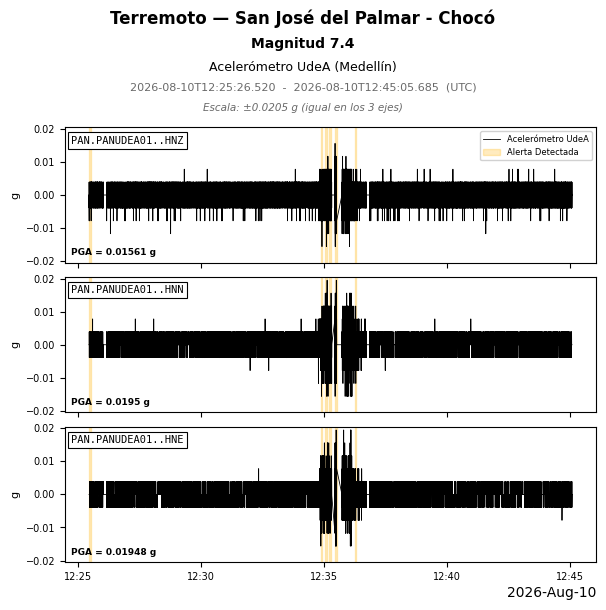

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_propia_g_UTC.png  (900x900 px)  [UTC]


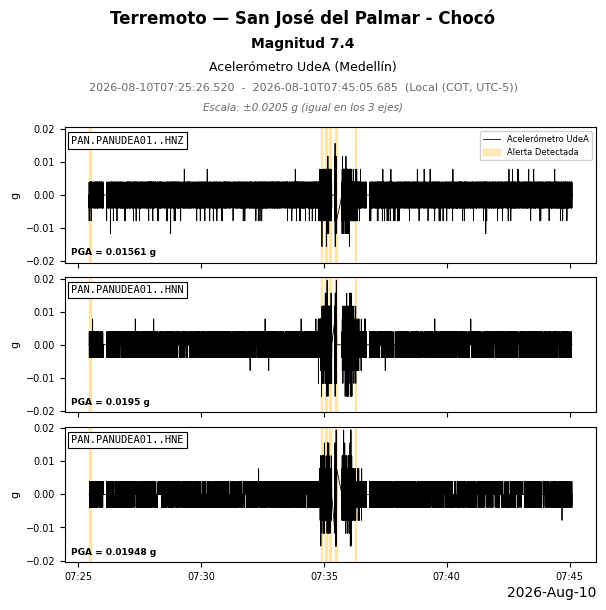

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_propia_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [45]:
serie_propia_mseed_dbb_g = _serie_unidad(t_utc_propia_rec_mseed_dbb, data_g_propia_rec_mseed_dbb, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")

plot_sgc_style(serie_propia_mseed_dbb_g, unidad="g",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_mseed_waveform_propia_g.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


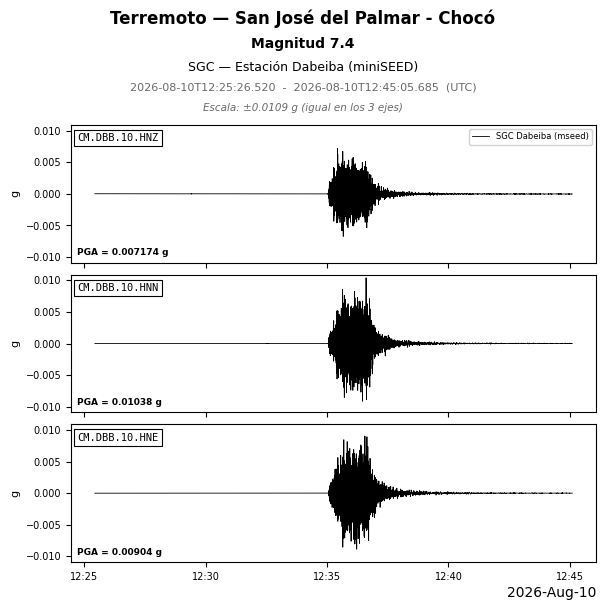

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_sgc_g_UTC.png  (900x900 px)  [UTC]


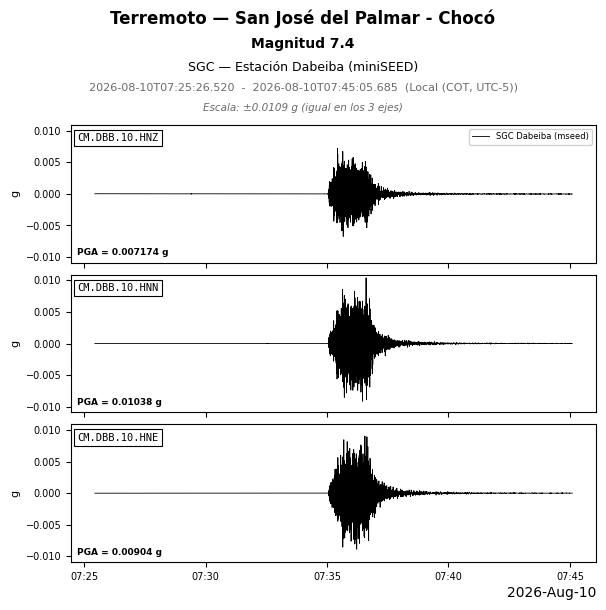

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_sgc_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [46]:
serie_sgc_mseed_dbb_g = _serie_unidad(t_utc_mseed_dbb, mseed_dbb_cms2, ID_DABEIBA_MSEED, "SGC Dabeiba (mseed)", COLOR_PROPIA, "cm/s²", "g")

plot_sgc_style(serie_sgc_mseed_dbb_g, unidad="g",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_mseed_waveform_sgc_g.png",
               estaciones=ESTACIONES_DABEIBA_MSEED,
               alert_windows=None)


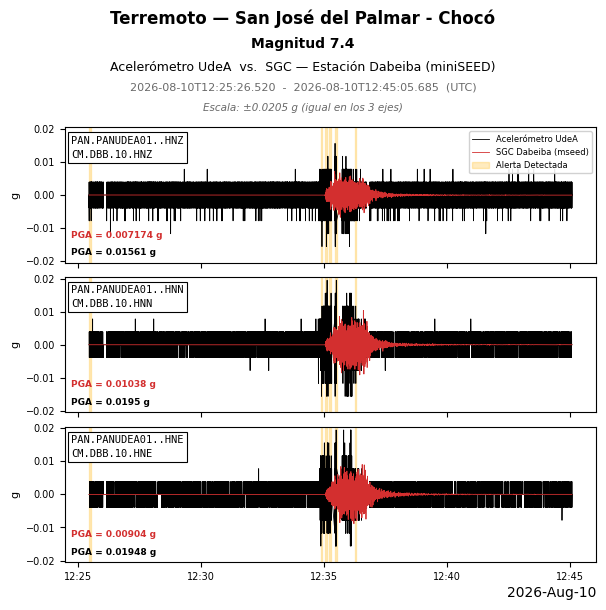

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_g_UTC.png  (900x900 px)  [UTC]


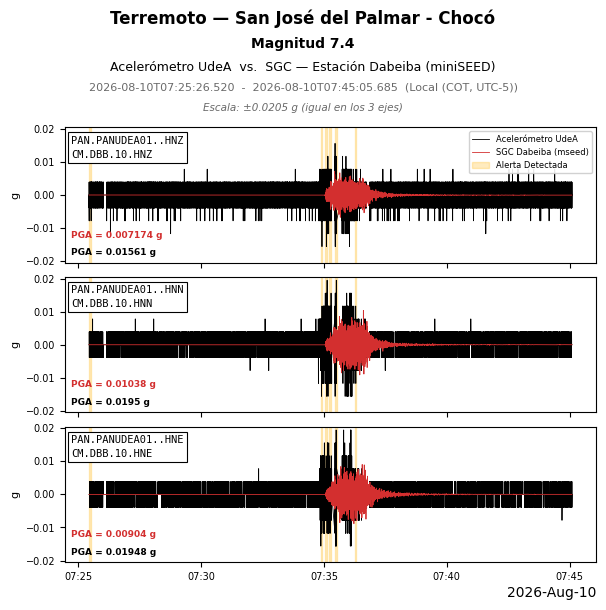

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [47]:
serie_sgc_mseed_dbb_g_rojo = _serie_unidad(t_utc_mseed_dbb, mseed_dbb_cms2, ID_DABEIBA_MSEED, "SGC Dabeiba (mseed)", COLOR_SGC, "cm/s²", "g")
serie_junta_mseed_dbb_g = _combinar(serie_propia_mseed_dbb_g, serie_sgc_mseed_dbb_g_rojo)

plot_sgc_style(serie_junta_mseed_dbb_g, unidad="g",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_mseed_waveform_g.png",
               estaciones=ESTACIONES_AMBAS_DABEIBA_MSEED,
               alert_windows=recon["alert_windows"])


### Dabeiba (mseed) -- cm/s²

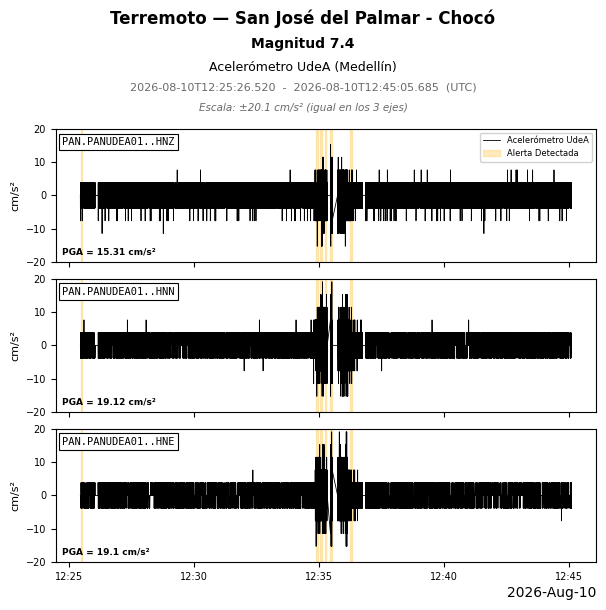

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_propia_cms2_UTC.png  (900x900 px)  [UTC]


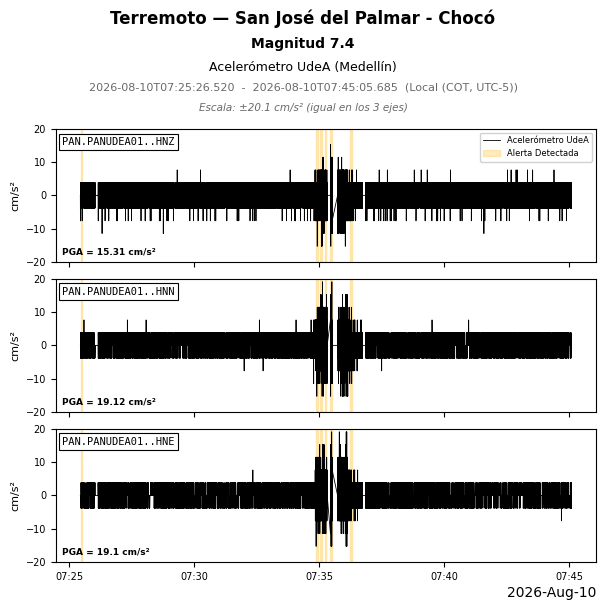

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_propia_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [48]:
serie_propia_mseed_dbb_cms2 = _serie_unidad(t_utc_propia_rec_mseed_dbb, data_g_propia_rec_mseed_dbb, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")

plot_sgc_style(serie_propia_mseed_dbb_cms2, unidad="cm/s²",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_mseed_waveform_propia_cms2.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


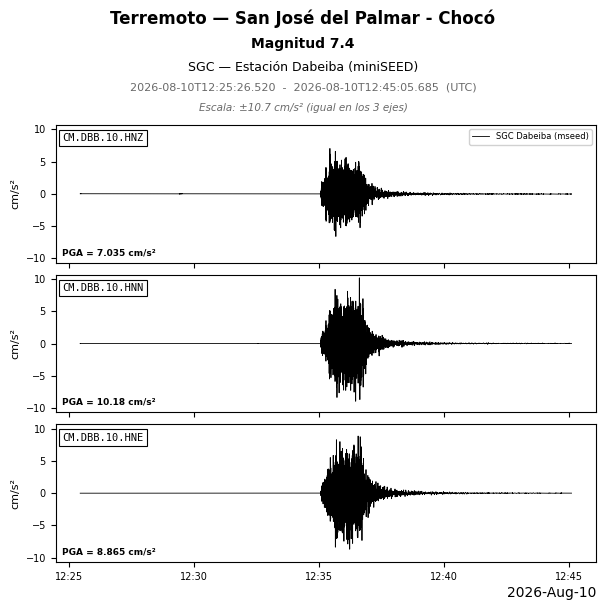

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_sgc_cms2_UTC.png  (900x900 px)  [UTC]


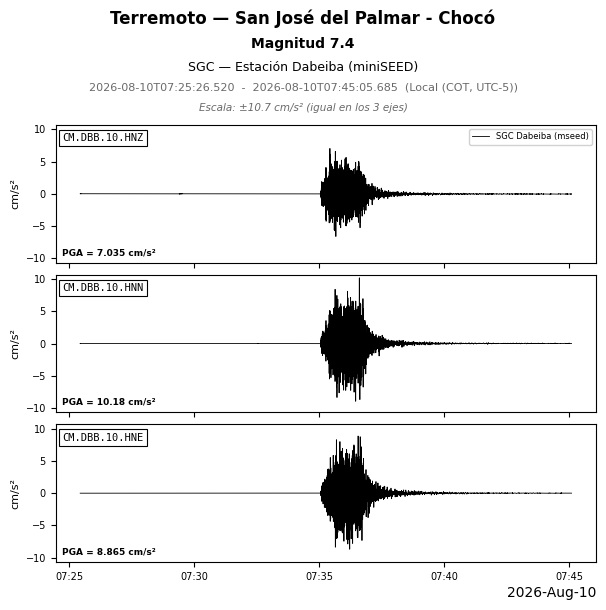

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_sgc_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [49]:
serie_sgc_mseed_dbb_cms2 = _serie_unidad(t_utc_mseed_dbb, mseed_dbb_cms2, ID_DABEIBA_MSEED, "SGC Dabeiba (mseed)", COLOR_PROPIA, "cm/s²", "cm/s²")

plot_sgc_style(serie_sgc_mseed_dbb_cms2, unidad="cm/s²",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_mseed_waveform_sgc_cms2.png",
               estaciones=ESTACIONES_DABEIBA_MSEED,
               alert_windows=None)


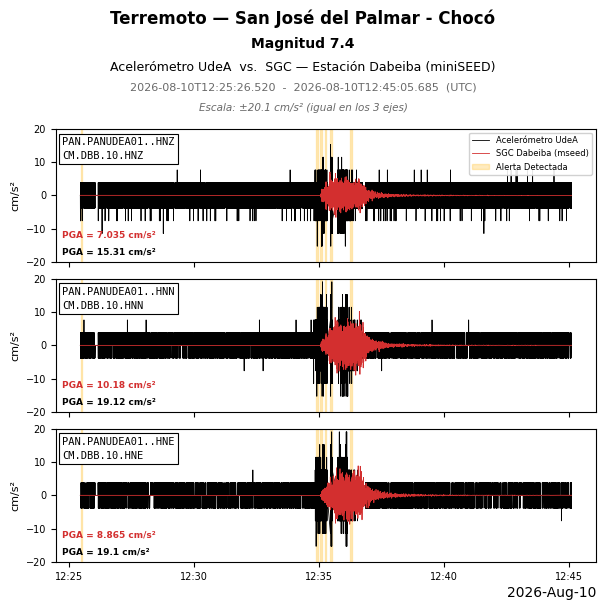

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_UTC.png  (900x900 px)  [UTC]


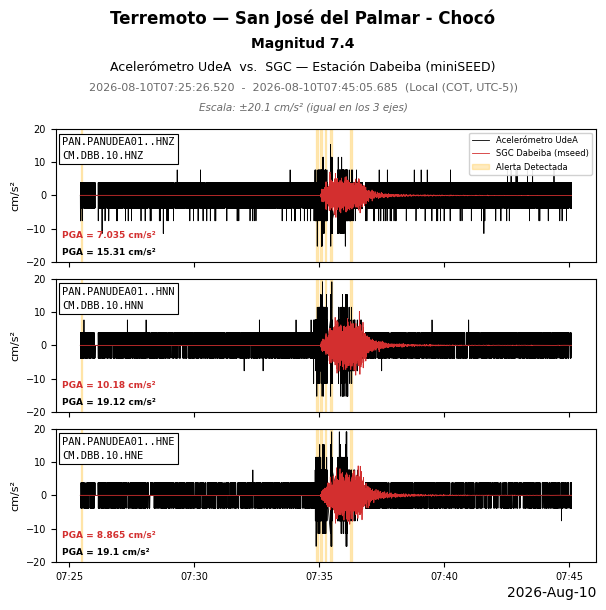

  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [50]:
serie_sgc_mseed_dbb_cms2_rojo = _serie_unidad(t_utc_mseed_dbb, mseed_dbb_cms2, ID_DABEIBA_MSEED, "SGC Dabeiba (mseed)", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_mseed_dbb_cms2 = _combinar(serie_propia_mseed_dbb_cms2, serie_sgc_mseed_dbb_cms2_rojo)

plot_sgc_style(serie_junta_mseed_dbb_cms2, unidad="cm/s²",
               save_path=DIR_DABEIBA / "dabeiba_DBB_10_mseed_waveform.png",
               estaciones=ESTACIONES_AMBAS_DABEIBA_MSEED,
               alert_windows=recon["alert_windows"])


## §14 — Comparación con una tercera estación del SGC: Riosucio, Caldas (RIO2C)

Mismo procedimiento que con Dabeiba y Pereira, pero para la estación RIO2C
del SGC en Riosucio, Caldas (80 km del epicentro -- muy cerca de Pereira). El
registro real empieza en `INICIO_RIOSUCIO_UTC` (`2026-08-10 12:33:57 UTC`,
mismo patrón de 30 s antes del origen del sismo confirmado en las otras dos
estaciones).

In [51]:
header_riosucio, riosucio_cms2, riosucio_g, t_utc_riosucio, cols_riosucio = parse_anc(RUTA_ANC_RIOSUCIO, INICIO_RIOSUCIO_UTC)

assert riosucio_cms2.shape == (header_riosucio["n_datos"], 3), "Número de filas/columnas inesperado en el .anc"

print("-- Cabecera SGC -- Estación Riosucio (RIO2C) ------------------")
print(f"  Evento               : {header_riosucio['descripcion_evento']}")
print(f"  Origen del sismo (UTC): {header_riosucio['evento_datetime_utc']}  M={header_riosucio['magnitud']}")
print(f"  Inicio del registro  : {t_utc_riosucio[0]}  ->  fin: {t_utc_riosucio[-1]}  UTC")
print(f"  Estación             : {header_riosucio['codigo_estacion']}  lat={header_riosucio['lat_estacion']}  lon={header_riosucio['lon_estacion']}")
print(f"  Distancia epicentral : {header_riosucio['distancia_epicentral']} km")
print(f"  Muestras             : {header_riosucio['n_datos']}  ({header_riosucio['sample_rate']} Hz, {header_riosucio['duracion_s']} s)")
print(f"  Columnas en archivo  : {cols_riosucio}")

ESTACIONES_RIOSUCIO = "SGC — Estación Riosucio (RIO2C)"
ESTACIONES_AMBAS_RIOSUCIO = "Acelerómetro UdeA  vs.  SGC — Estación Riosucio (RIO2C)"


-- Cabecera SGC -- Estación Riosucio (RIO2C) ------------------
  Evento               : San Jos? del Palmar - Choc?, Colombia
  Origen del sismo (UTC): 2026-08-10 12:34:27+00:00  M=7.4
  Inicio del registro  : 2026-08-10T12:33:57.000000  ->  fin: 2026-08-10T12:42:27.000000  UTC
  Estación             : RIO2C  lat=5.4211  lon=-75.7104
  Distancia epicentral : 80.0 km
  Muestras             : 102001  (200 Hz, 510.0 s)
  Columnas en archivo  : ['EW', 'VER', 'NS']


### Ventana de comparación con Riosucio

Se recorta la señal propia reconstruida a la ventana temporal real del
registro de Riosucio (510 s, iniciando en `INICIO_RIOSUCIO_UTC`).

In [52]:
t0_riosucio = t_utc_riosucio[0]
t1_riosucio = t_utc_riosucio[-1]

mask_ventana_riosucio = (t_utc_propia >= t0_riosucio) & (t_utc_propia <= t1_riosucio)
if not mask_ventana_riosucio.any():
    raise ValueError("La ventana del registro de Riosucio no se solapa con la reconstrucción propia.")

t_utc_propia_rec_riosucio  = t_utc_propia[mask_ventana_riosucio]
data_g_propia_rec_riosucio = recon["data_g"][mask_ventana_riosucio]

print(f"Ventana de comparación: {t0_riosucio} -> {t1_riosucio}  UTC")
print(f"Muestras propias en la ventana: {mask_ventana_riosucio.sum()}  /  muestras SGC: {len(t_utc_riosucio)}")


Ventana de comparación: 2026-08-10T12:33:57.000000 -> 2026-08-10T12:42:27.000000  UTC
Muestras propias en la ventana: 102001  /  muestras SGC: 102001


### Riosucio -- g

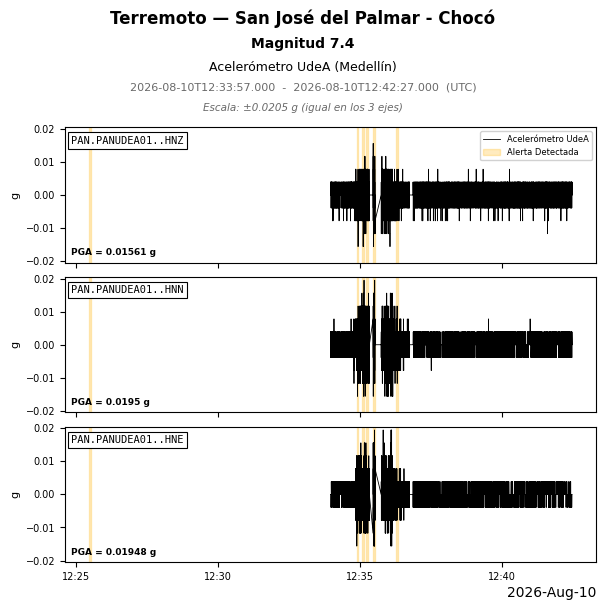

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_propia_g_UTC.png  (900x900 px)  [UTC]


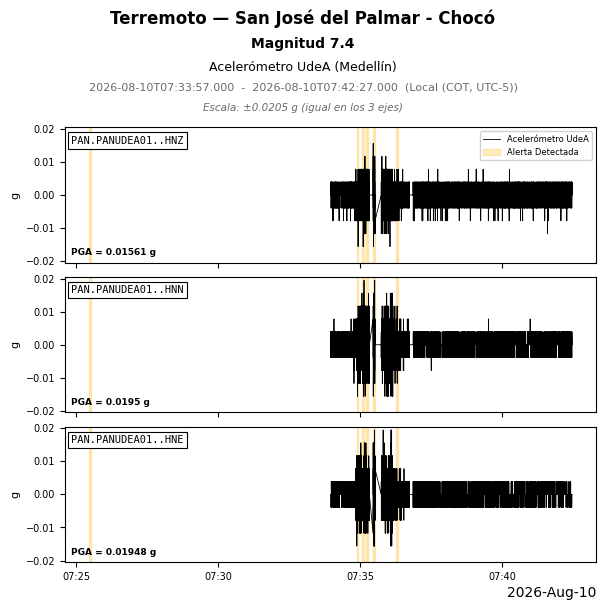

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_propia_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [53]:
serie_propia_riosucio_g = _serie_unidad(t_utc_propia_rec_riosucio, data_g_propia_rec_riosucio, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")

plot_sgc_style(serie_propia_riosucio_g, unidad="g",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_waveform_propia_g.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


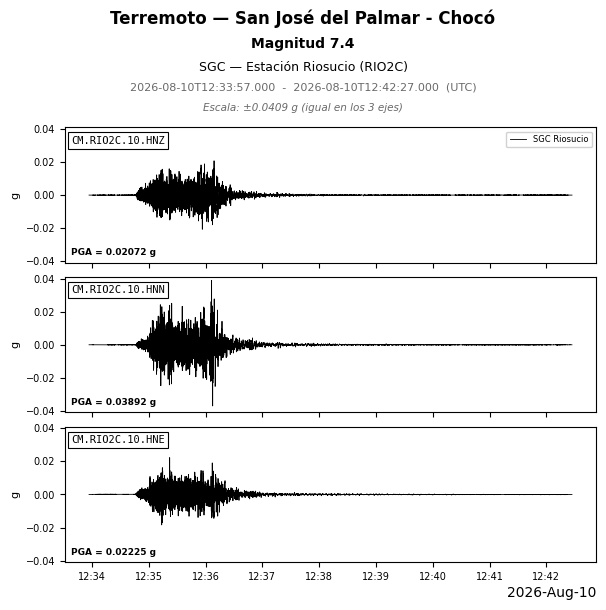

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_sgc_g_UTC.png  (900x900 px)  [UTC]


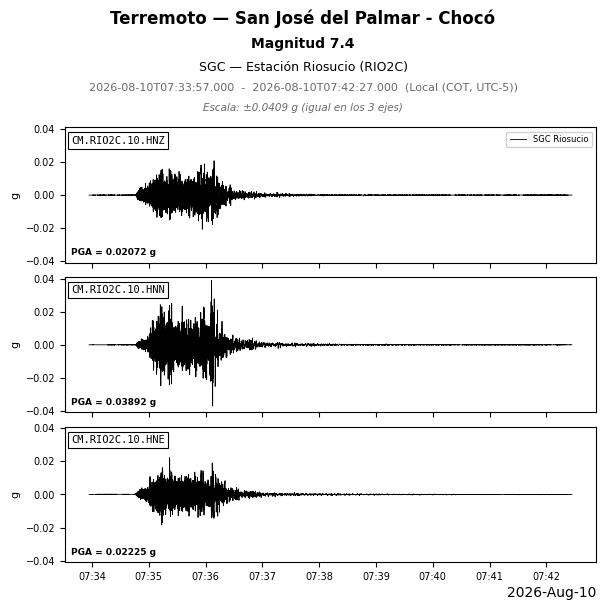

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_sgc_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [54]:
serie_sgc_riosucio_g = _serie_unidad(t_utc_riosucio, riosucio_cms2, ID_RIOSUCIO, "SGC Riosucio", COLOR_PROPIA, "cm/s²", "g")

plot_sgc_style(serie_sgc_riosucio_g, unidad="g",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_waveform_sgc_g.png",
               estaciones=ESTACIONES_RIOSUCIO,
               alert_windows=None)


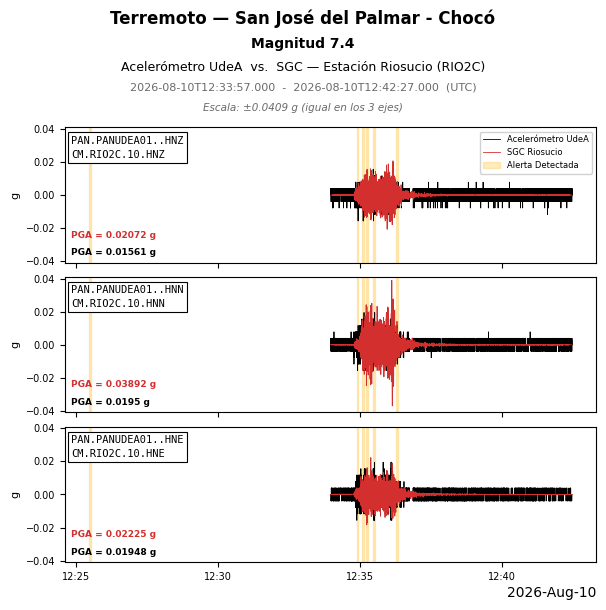

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_g_UTC.png  (900x900 px)  [UTC]


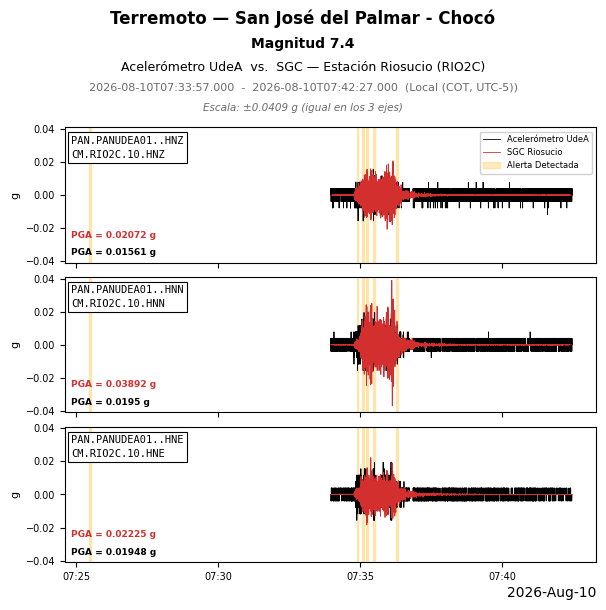

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [55]:
serie_sgc_riosucio_g_rojo = _serie_unidad(t_utc_riosucio, riosucio_cms2, ID_RIOSUCIO, "SGC Riosucio", COLOR_SGC, "cm/s²", "g")
serie_junta_riosucio_g = _combinar(serie_propia_riosucio_g, serie_sgc_riosucio_g_rojo)

plot_sgc_style(serie_junta_riosucio_g, unidad="g",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_waveform_g.png",
               estaciones=ESTACIONES_AMBAS_RIOSUCIO,
               alert_windows=recon["alert_windows"])


### Riosucio -- cm/s²

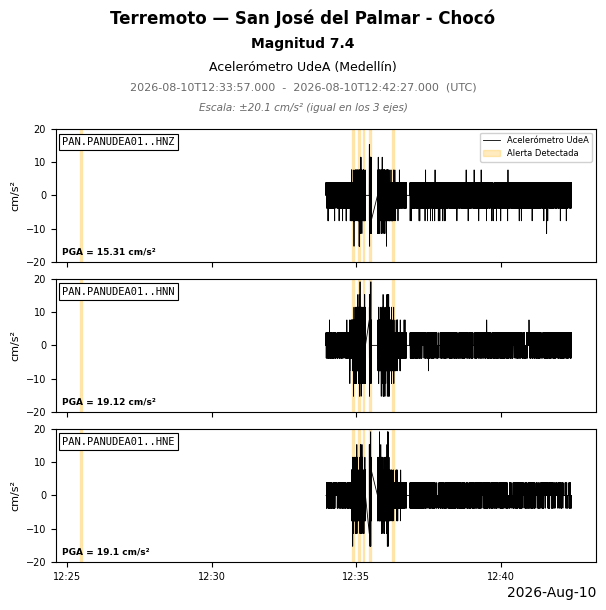

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_propia_cms2_UTC.png  (900x900 px)  [UTC]


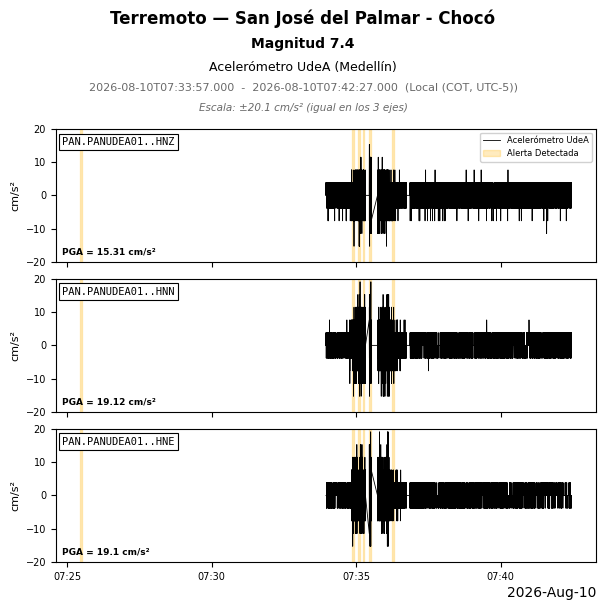

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_propia_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [56]:
serie_propia_riosucio_cms2 = _serie_unidad(t_utc_propia_rec_riosucio, data_g_propia_rec_riosucio, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")

plot_sgc_style(serie_propia_riosucio_cms2, unidad="cm/s²",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_waveform_propia_cms2.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


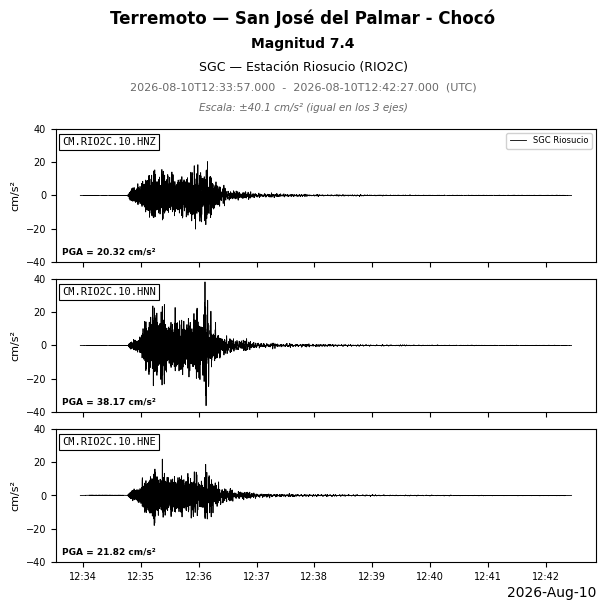

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_sgc_cms2_UTC.png  (900x900 px)  [UTC]


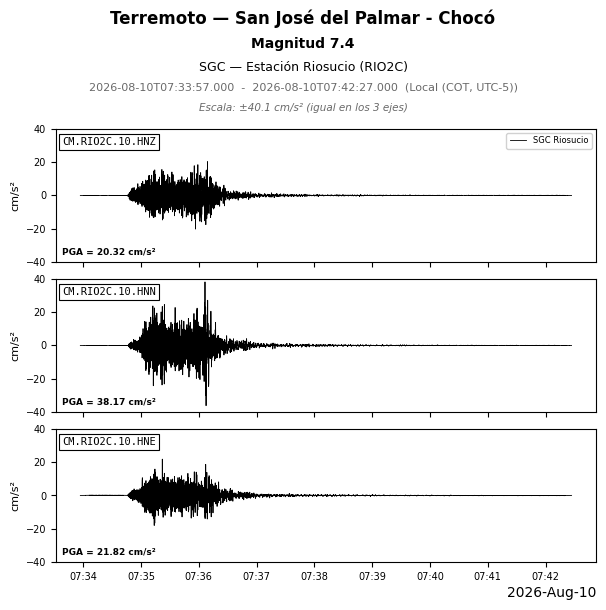

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_sgc_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [57]:
serie_sgc_riosucio_cms2 = _serie_unidad(t_utc_riosucio, riosucio_cms2, ID_RIOSUCIO, "SGC Riosucio", COLOR_PROPIA, "cm/s²", "cm/s²")

plot_sgc_style(serie_sgc_riosucio_cms2, unidad="cm/s²",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_waveform_sgc_cms2.png",
               estaciones=ESTACIONES_RIOSUCIO,
               alert_windows=None)


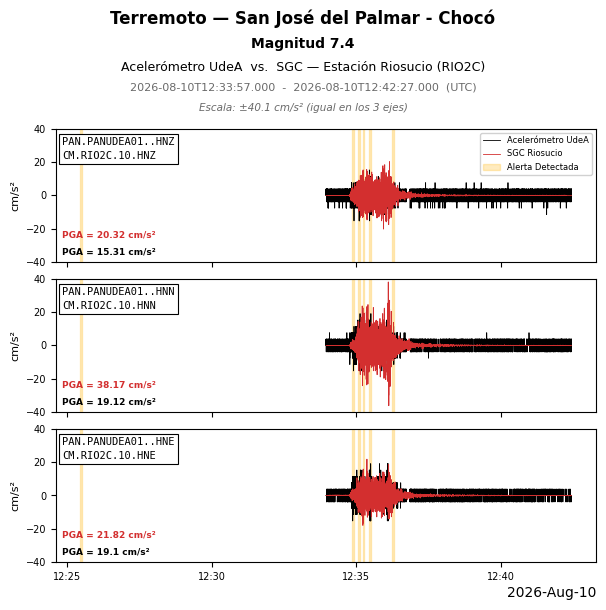

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_UTC.png  (900x900 px)  [UTC]


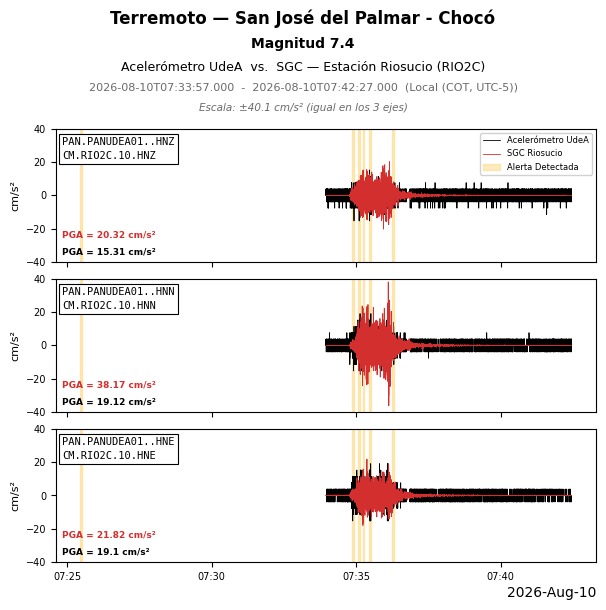

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_waveform_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [58]:
serie_sgc_riosucio_cms2_rojo = _serie_unidad(t_utc_riosucio, riosucio_cms2, ID_RIOSUCIO, "SGC Riosucio", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_riosucio_cms2 = _combinar(serie_propia_riosucio_cms2, serie_sgc_riosucio_cms2_rojo)

plot_sgc_style(serie_junta_riosucio_cms2, unidad="cm/s²",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_waveform.png",
               estaciones=ESTACIONES_AMBAS_RIOSUCIO,
               alert_windows=recon["alert_windows"])


## §15 — Riosucio (RIO2C) a partir del `.mseed` crudo

Igual que Dabeiba en §13: un solo archivo `RIO2C.mseed` con varias trazas
(`CM.RIO2C.00.HH*` a 100 Hz y `CM.RIO2C.10.HN*` a 200 Hz). Se usan únicamente
los canales **`CM.RIO2C.10.HN*`** -- los mismos que venimos usando (coinciden
con `ID_RIOSUCIO = "CM.RIO2C.10"`). Se calibran cuentas → cm/s² por
correlación cruzada contra el `.anc` de Riosucio, reutilizando
`calibrar_canal_mseed()` de §12.

In [59]:
st_rio_completo = obspy_read(str(RUTA_MSEED_RIOSUCIO_TODO))
st_rio_hn = st_rio_completo.select(location="10", channel="HN*")

trazas_mseed_riosucio = {}
print("-- Trazas .mseed crudas -- Riosucio (CM.RIO2C.10.HN*) -----------------")
for tr in st_rio_hn:
    canal_key = tr.stats.channel
    trazas_mseed_riosucio[canal_key] = tr
    print(f"  {canal_key}: {tr.id}  {tr.stats.starttime} -> {tr.stats.endtime}  "
          f"{tr.stats.sampling_rate} Hz  {tr.stats.npts} muestras  "
          f"(cuentas: min={tr.data.min()}, max={tr.data.max()})")


-- Trazas .mseed crudas -- Riosucio (CM.RIO2C.10.HN*) -----------------
  HNE: CM.RIO2C.10.HNE  2026-08-10T12:25:23.940000Z -> 2026-08-10T12:45:04.710000Z  200.0 Hz  236155 muestras  (cuentas: min=-189740, max=-20742)
  HNN: CM.RIO2C.10.HNN  2026-08-10T12:25:24.210000Z -> 2026-08-10T12:45:04.190000Z  200.0 Hz  235997 muestras  (cuentas: min=-414702, max=-99003)
  HNZ: CM.RIO2C.10.HNZ  2026-08-10T12:25:25.355000Z -> 2026-08-10T12:45:06.055000Z  200.0 Hz  236141 muestras  (cuentas: min=-149281, max=22820)


### Calibración por correlación cruzada contra el `.anc` de Riosucio

In [60]:
print("Calibrando canales .mseed de Riosucio contra el .anc (misma estación)...")
calibracion_mseed_riosucio = {}
for i, canal in enumerate(["HNE", "HNN", "HNZ"]):
    resultado = calibrar_canal_mseed(trazas_mseed_riosucio[canal], riosucio_cms2[:, i], header_riosucio["sample_dt"])
    calibracion_mseed_riosucio[canal] = resultado
    print(f"  {canal}: escala={resultado['escala']:.4e} cm/s²/cuenta  R²={resultado['r2']:.5f}  "
          f"inicio real implícito del .anc: {resultado['inicio_anc_implicito']}")


Calibrando canales .mseed de Riosucio contra el .anc (misma estación)...
  HNE: escala=2.3562e-04 cm/s²/cuenta  R²=0.99982  inicio real implícito del .anc: 2026-08-10 12:33:57+00:00
  HNN: escala=2.3564e-04 cm/s²/cuenta  R²=0.99993  inicio real implícito del .anc: 2026-08-10 12:33:57+00:00
  HNZ: escala=2.3562e-04 cm/s²/cuenta  R²=0.99989  inicio real implícito del .anc: 2026-08-10 12:33:57+00:00


### Aplicar calibración y alinear los 3 canales (Riosucio)

In [61]:
señales_cal_cms2_rio, t_por_canal_rio = {}, {}
for canal in ["HNE", "HNN", "HNZ"]:
    tr = trazas_mseed_riosucio[canal]
    c = calibracion_mseed_riosucio[canal]
    x = tr.data.astype(np.float64) - np.median(tr.data.astype(np.float64))
    señales_cal_cms2_rio[canal] = x * c["escala"]
    t0 = np.datetime64(tr.stats.starttime.datetime)
    dt_mseed = 1.0 / tr.stats.sampling_rate
    t_por_canal_rio[canal] = t0 + (np.arange(tr.stats.npts) * dt_mseed * 1e6).astype("int64").astype("timedelta64[us]")

t_inicio_comun_rio = max(t_por_canal_rio[c][0] for c in t_por_canal_rio)
t_fin_comun_rio    = min(t_por_canal_rio[c][-1] for c in t_por_canal_rio)

mseed_rio_cms2 = np.column_stack([
    señales_cal_cms2_rio[canal][(t_por_canal_rio[canal] >= t_inicio_comun_rio) & (t_por_canal_rio[canal] <= t_fin_comun_rio)]
    for canal in ["HNE", "HNN", "HNZ"]
])
t_utc_mseed_rio = t_por_canal_rio["HNE"][(t_por_canal_rio["HNE"] >= t_inicio_comun_rio) & (t_por_canal_rio["HNE"] <= t_fin_comun_rio)]

n_comun_rio = min(mseed_rio_cms2.shape[0], len(t_utc_mseed_rio))
mseed_rio_cms2  = mseed_rio_cms2[:n_comun_rio]
t_utc_mseed_rio = t_utc_mseed_rio[:n_comun_rio]
mseed_rio_g     = mseed_rio_cms2 / G_TO_CMS2

print(f"Ventana común de los 3 canales: {t_utc_mseed_rio[0]} -> {t_utc_mseed_rio[-1]}  UTC  "
      f"({n_comun_rio} muestras, {n_comun_rio/200:.1f} s)")

ID_RIOSUCIO_MSEED = ID_RIOSUCIO  # mismo NSLC (CM.RIO2C.10) -- confirmado en la cabecera del .mseed
ESTACIONES_RIOSUCIO_MSEED = "SGC — Estación Riosucio (RIO2C, miniSEED)"
ESTACIONES_AMBAS_RIOSUCIO_MSEED = "Acelerómetro UdeA  vs.  SGC — Estación Riosucio (RIO2C, miniSEED)"


Ventana común de los 3 canales: 2026-08-10T12:25:25.355000 -> 2026-08-10T12:45:04.190000  UTC  (235768 muestras, 1178.8 s)


### Ventana de comparación (mseed, Riosucio)

Se recorta la señal propia reconstruida a la ventana común de los 3 canales
`.mseed` de Riosucio.

In [62]:
mask_ventana_mseed_rio = (t_utc_propia >= t_utc_mseed_rio[0]) & (t_utc_propia <= t_utc_mseed_rio[-1])
if not mask_ventana_mseed_rio.any():
    raise ValueError("La ventana del .mseed de Riosucio no se solapa con la reconstrucción propia.")

t_utc_propia_rec_mseed_rio  = t_utc_propia[mask_ventana_mseed_rio]
data_g_propia_rec_mseed_rio = recon["data_g"][mask_ventana_mseed_rio]

print(f"Ventana de comparación: {t_utc_mseed_rio[0]} -> {t_utc_mseed_rio[-1]}  UTC")
print(f"Muestras propias en la ventana: {mask_ventana_mseed_rio.sum()}  /  muestras mseed: {n_comun_rio}")


Ventana de comparación: 2026-08-10T12:25:25.355000 -> 2026-08-10T12:45:04.190000  UTC
Muestras propias en la ventana: 235768  /  muestras mseed: 235768


### Riosucio (mseed) -- g

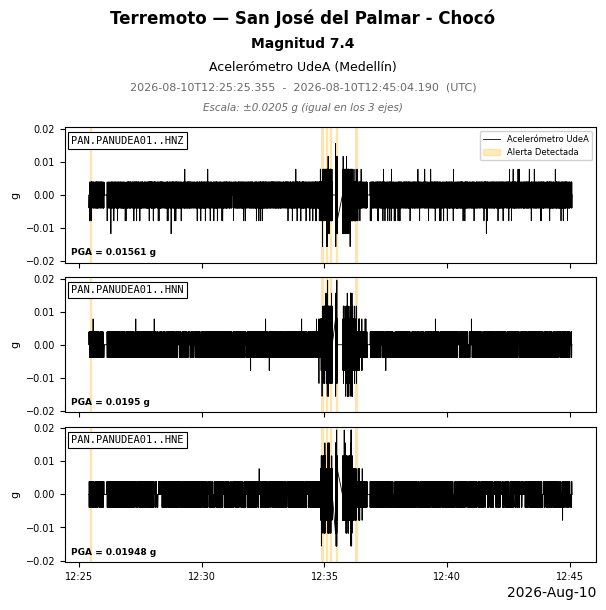

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_propia_g_UTC.png  (900x900 px)  [UTC]


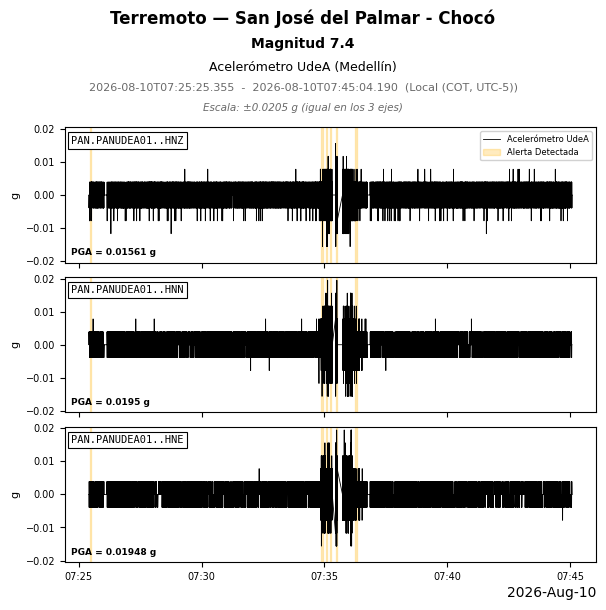

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_propia_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [63]:
serie_propia_mseed_rio_g = _serie_unidad(t_utc_propia_rec_mseed_rio, data_g_propia_rec_mseed_rio, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")

plot_sgc_style(serie_propia_mseed_rio_g, unidad="g",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_mseed_waveform_propia_g.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


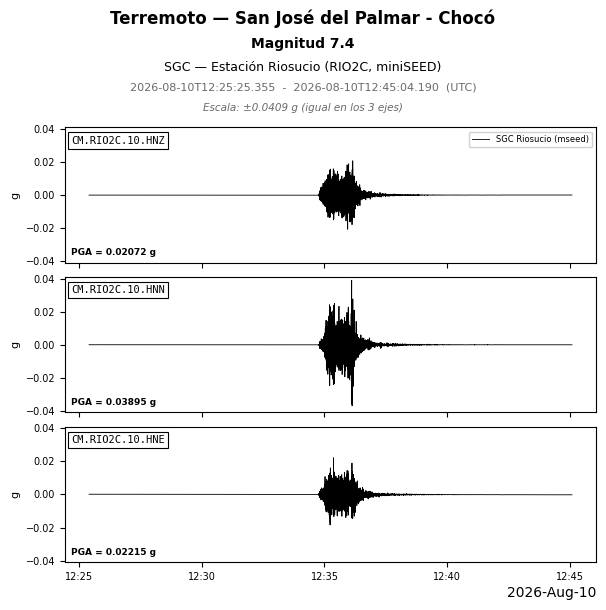

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_sgc_g_UTC.png  (900x900 px)  [UTC]


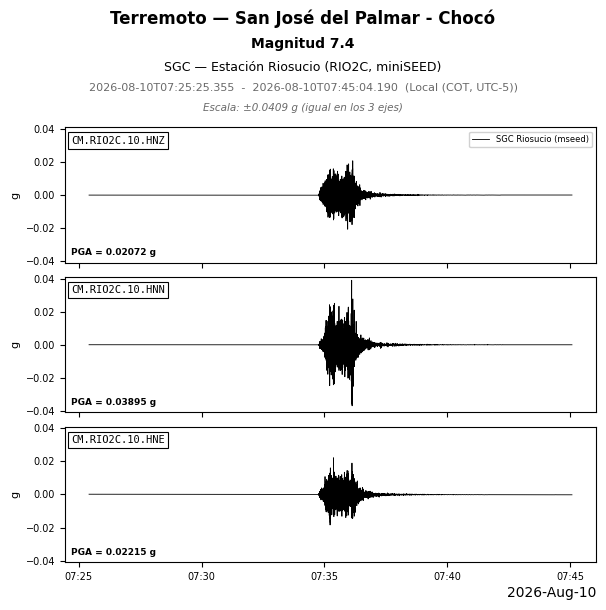

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_sgc_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [64]:
serie_sgc_mseed_rio_g = _serie_unidad(t_utc_mseed_rio, mseed_rio_cms2, ID_RIOSUCIO_MSEED, "SGC Riosucio (mseed)", COLOR_PROPIA, "cm/s²", "g")

plot_sgc_style(serie_sgc_mseed_rio_g, unidad="g",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_mseed_waveform_sgc_g.png",
               estaciones=ESTACIONES_RIOSUCIO_MSEED,
               alert_windows=None)


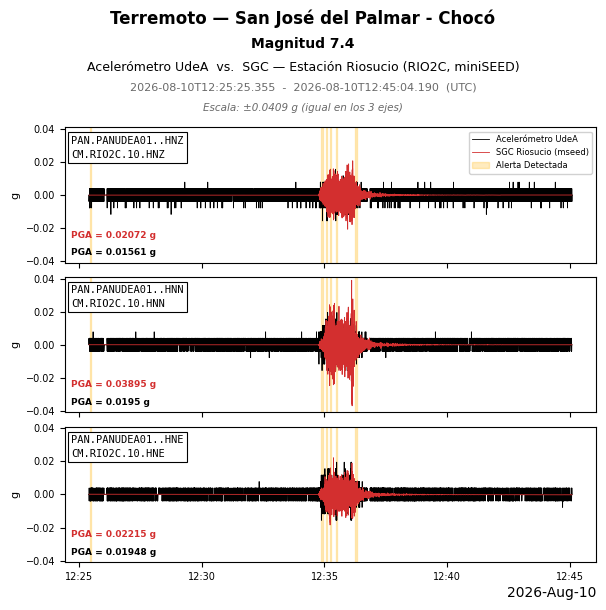

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_g_UTC.png  (900x900 px)  [UTC]


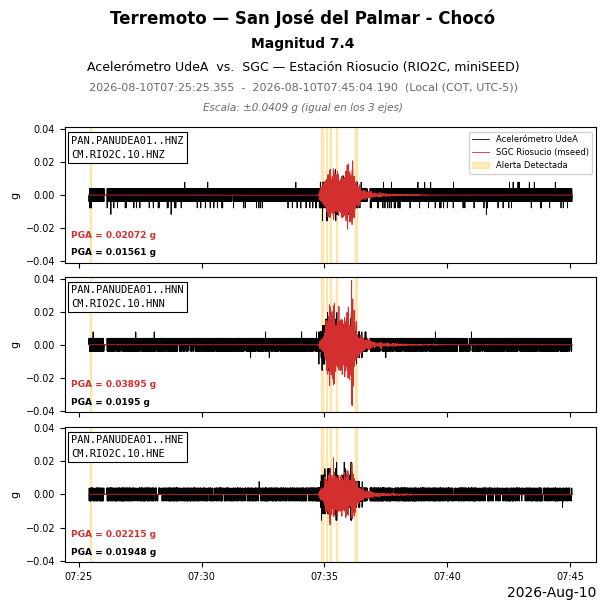

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [65]:
serie_sgc_mseed_rio_g_rojo = _serie_unidad(t_utc_mseed_rio, mseed_rio_cms2, ID_RIOSUCIO_MSEED, "SGC Riosucio (mseed)", COLOR_SGC, "cm/s²", "g")
serie_junta_mseed_rio_g = _combinar(serie_propia_mseed_rio_g, serie_sgc_mseed_rio_g_rojo)

plot_sgc_style(serie_junta_mseed_rio_g, unidad="g",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_mseed_waveform_g.png",
               estaciones=ESTACIONES_AMBAS_RIOSUCIO_MSEED,
               alert_windows=recon["alert_windows"])


### Riosucio (mseed) -- cm/s²

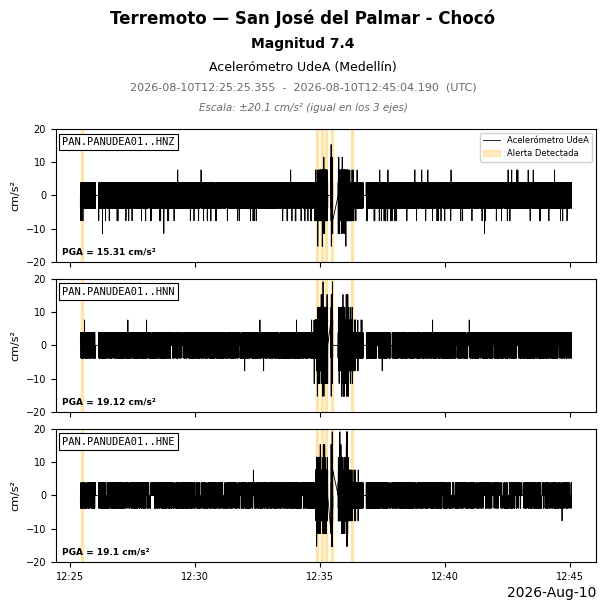

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_propia_cms2_UTC.png  (900x900 px)  [UTC]


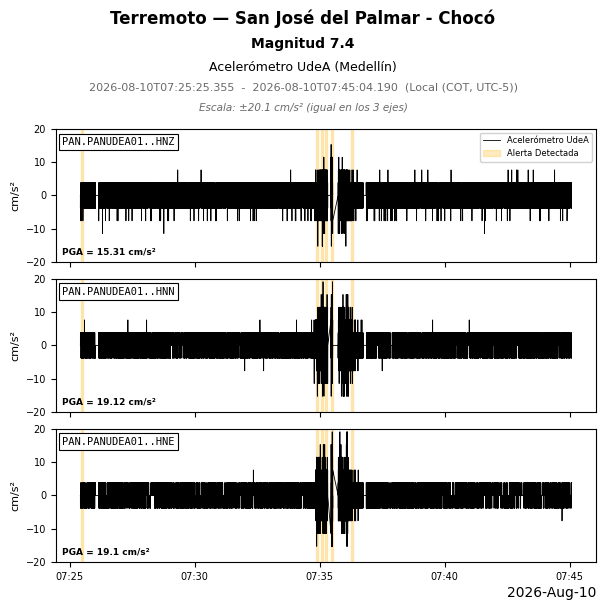

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_propia_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [66]:
serie_propia_mseed_rio_cms2 = _serie_unidad(t_utc_propia_rec_mseed_rio, data_g_propia_rec_mseed_rio, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")

plot_sgc_style(serie_propia_mseed_rio_cms2, unidad="cm/s²",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_mseed_waveform_propia_cms2.png",
               estaciones=ESTACIONES_PROPIA,
               alert_windows=recon["alert_windows"])


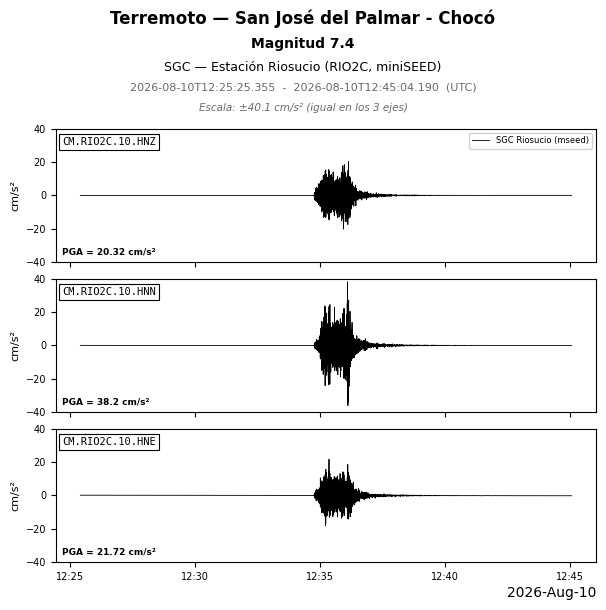

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_sgc_cms2_UTC.png  (900x900 px)  [UTC]


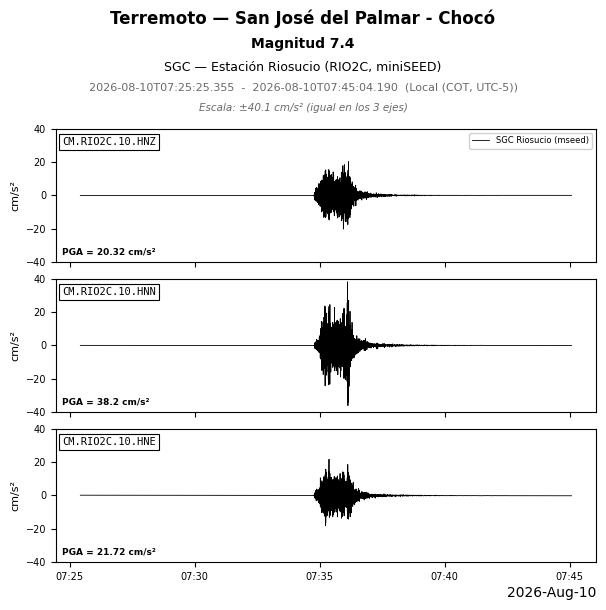

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_sgc_cms2_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [67]:
serie_sgc_mseed_rio_cms2 = _serie_unidad(t_utc_mseed_rio, mseed_rio_cms2, ID_RIOSUCIO_MSEED, "SGC Riosucio (mseed)", COLOR_PROPIA, "cm/s²", "cm/s²")

plot_sgc_style(serie_sgc_mseed_rio_cms2, unidad="cm/s²",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_mseed_waveform_sgc_cms2.png",
               estaciones=ESTACIONES_RIOSUCIO_MSEED,
               alert_windows=None)


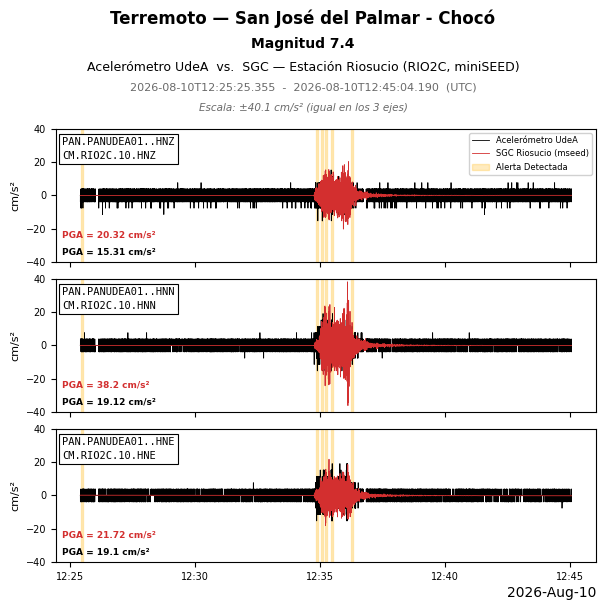

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_UTC.png  (900x900 px)  [UTC]


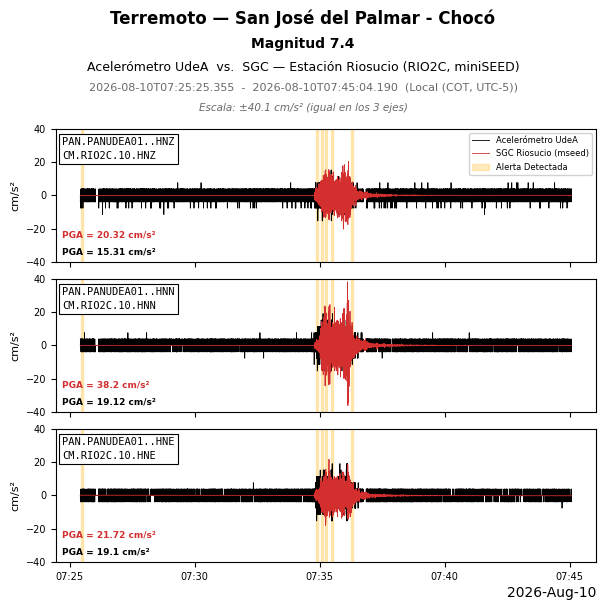

  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [68]:
serie_sgc_mseed_rio_cms2_rojo = _serie_unidad(t_utc_mseed_rio, mseed_rio_cms2, ID_RIOSUCIO_MSEED, "SGC Riosucio (mseed)", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_mseed_rio_cms2 = _combinar(serie_propia_mseed_rio_cms2, serie_sgc_mseed_rio_cms2_rojo)

plot_sgc_style(serie_junta_mseed_rio_cms2, unidad="cm/s²",
               save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_mseed_waveform.png",
               estaciones=ESTACIONES_AMBAS_RIOSUCIO_MSEED,
               alert_windows=recon["alert_windows"])


## §16 — Animaciones de la comparación UdeA vs. SGC

Versión animada de la gráfica "junta" (superpuesta) de cada estación: la
traza se va revelando progresivamente cuadro a cuadro, como un sismógrafo
dibujando en tiempo real. Las franjas ámbar "Alerta Detectada" **también
están animadas**: no aparecen estáticas desde el primer cuadro, sino que se
revelan y van creciendo justo cuando el "frente de onda" (la traza que se
revela) llega y pasa por ese instante -- igual que si el sismógrafo marcara
la alerta al vivo. `crear_animacion_sgc_style()` reutiliza exactamente el
mismo formato de encabezado/paneles/leyenda/PGA que `plot_sgc_style()` (§6)
y, al igual que esa función, genera automáticamente **las dos zonas horarias
(UTC y hora local de Colombia)** en cada llamada -- por eso solo hace falta
una llamada por combinación estación × unidad (g / cm/s²). Se guardan como
GIF.

In [69]:
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Patch


def crear_animacion_sgc_style(series_por_componente, unidad, save_path, estaciones=None,
                               alert_windows=None, figsize=(6, 6), n_frames=50, fps=10):
    """
    Versión animada de plot_sgc_style(): genera DOS animaciones (UTC y hora
    local de Colombia, mismo mecanismo que _ZONAS_HORARIAS/plot_sgc_style),
    revelando las trazas progresivamente cuadro a cuadro en vez de dibujarlas
    de una vez. Mismo encabezado de 5 líneas, casillas NSLC, PGA, leyenda y
    franjas de alerta que la versión estática -- pero las franjas de alerta
    también se animan: aparecen y van creciendo recién cuando el "frente de
    onda" (la traza que se revela) llega a esa zona, en vez de estar ahí desde
    el primer cuadro. Se guardan como GIF.
    """
    save_path = pathlib.Path(save_path)
    for etiqueta_zona, sufijo, offset in _ZONAS_HORARIAS:
        ruta_zona = save_path.with_name(f"{save_path.stem}_{sufijo}{save_path.suffix}")
        _animar_sgc_style(series_por_componente, unidad, ruta_zona, etiqueta_zona, offset,
                           estaciones=estaciones, alert_windows=alert_windows, figsize=figsize,
                           n_frames=n_frames, fps=fps)


def _animar_sgc_style(series_por_componente, unidad, save_path, etiqueta_zona, offset,
                       estaciones, alert_windows, figsize, n_frames, fps):
    offset_td64 = np.timedelta64(offset)
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    t_min = min(s[0][0] for serie in series_por_componente.values() for s in serie) + offset_td64
    t_max = max(s[0][-1] for serie in series_por_componente.values() for s in serie) + offset_td64
    rango_tiempo = (f"{np.datetime_as_string(t_min, unit='ms')}  -  "
                     f"{np.datetime_as_string(t_max, unit='ms')}  ({etiqueta_zona})")

    limite_y = max(
        np.nanmax(np.abs(sig)) for serie in series_por_componente.values() for _, sig, _, _, _ in serie
    ) * 1.05

    fig.text(0.5, 0.995, UBICACION_EVENTO, ha="center", va="top", fontsize=12, fontweight="bold")
    fig.text(0.5, 0.950, MAGNITUD_EVENTO, ha="center", va="top", fontsize=10, fontweight="bold")
    if estaciones:
        fig.text(0.5, 0.910, estaciones, ha="center", va="top", fontsize=9)
    fig.text(0.5, 0.874, rango_tiempo, ha="center", va="top", fontsize=8, color="dimgray")
    fig.text(0.5, 0.840, f"Escala: ±{limite_y:.3g} {unidad} (igual en los 3 ejes)",
              ha="center", va="top", fontsize=7.5, style="italic", color="dimgray")

    # -- ventanas de alerta preconvertidas a la zona horaria de esta figura (datetime64,
    #    para comparar directamente contra el "cursor" de tiempo revelado cada cuadro) --
    alertas_zona = [(np.datetime64((t0 + offset).replace(tzinfo=None)),
                      np.datetime64((t1 + offset).replace(tzinfo=None)), score)
                     for t0, t1, score in (alert_windows or [])]

    lineas_por_fila = []
    parches_alerta_por_fila = [[] for _ in _ORDEN_FILAS]
    n_max_muestras = 0
    for fila, comp in enumerate(_ORDEN_FILAS):
        ax = axes[fila]
        canal = _CANAL_POR_COMP[comp]
        lineas_id, lineas_pga, lineas = [], [], []

        for i, (t, sig, codigo_base, nombre, color) in enumerate(series_por_componente[comp]):
            t_zona = t + offset_td64
            (linea,) = ax.plot(t_zona, sig, color=color, linewidth=0.6, label=nombre)
            linea.set_data([], [])
            lineas.append((linea, t_zona, sig))
            n_max_muestras = max(n_max_muestras, len(t_zona))
            lineas_id.append(f"{codigo_base}.HN{canal}")
            pga = np.nanmax(np.abs(sig))
            lineas_pga.append((f"PGA = {pga:.4g} {unidad}", color))

        ax.text(0.012, 0.94, "\n".join(lineas_id), transform=ax.transAxes, va="top", ha="left",
                fontsize=7.5, family="monospace", linespacing=1.5,
                bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", linewidth=0.8))
        for i, (txt, color) in enumerate(lineas_pga):
            ax.text(0.012, 0.04 + i * 0.13, txt, transform=ax.transAxes,
                    va="bottom", ha="left", fontsize=6.5, color=color, fontweight="bold")

        ax.set_ylabel(unidad, fontsize=8)
        ax.set_xlim(t_min, t_max)
        ax.set_ylim(-limite_y, limite_y)
        ax.tick_params(labelsize=7)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

        # -- las franjas de alerta NO se dibujan aquí (estáticas) -- se revelan cuadro a
        #    cuadro en actualizar(); la leyenda usa un parche "de mentira" (Patch) que no
        #    depende de que ya haya una franja dibujada en este primer cuadro --
        handles, labels = ax.get_legend_handles_labels()
        if alertas_zona:
            handles.append(Patch(facecolor=COLOR_ALERTA, alpha=0.25))
            labels.append("Alerta Detectada")
        if fila == 0 and labels:
            ax.legend(handles, labels, fontsize=6, loc="upper right", framealpha=0.9)

        lineas_por_fila.append(lineas)

    locator = mdates.AutoDateLocator()
    axes[-1].xaxis.set_major_locator(locator)
    axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    plt.setp(axes[-1].get_xticklabels(), fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.815], pad=0.5)

    indices = np.linspace(1, n_max_muestras, n_frames).astype(int)

    def actualizar(frame_i):
        idx = indices[frame_i]
        artistas = []
        cursor = None
        for lineas in lineas_por_fila:
            for linea, t_zona, sig in lineas:
                k = min(idx, len(t_zona))
                linea.set_data(t_zona[:k], sig[:k])
                artistas.append(linea)
                if k > 0:
                    ultimo = t_zona[k - 1]
                    if cursor is None or ultimo > cursor:
                        cursor = ultimo

        # -- revela/crece cada franja de alerta solo cuando el frente de onda (cursor)
        #    ya pasó por su instante de inicio -- crece hasta su fin, o hasta donde
        #    vaya el frente si todavía está pasando por esa zona --
        if alertas_zona and cursor is not None:
            for fila_idx, ax in enumerate(axes):
                for parche in parches_alerta_por_fila[fila_idx]:
                    parche.remove()
                parches_alerta_por_fila[fila_idx] = []
                for t0_a, t1_a, score in alertas_zona:
                    if cursor >= t0_a:
                        t1_visible = min(cursor, t1_a)
                        parche = ax.axvspan(t0_a, t1_visible, color=COLOR_ALERTA, alpha=0.25)
                        parches_alerta_por_fila[fila_idx].append(parche)
                        artistas.append(parche)
        return artistas

    anim = FuncAnimation(fig, actualizar, frames=n_frames, interval=1000 / fps, blit=False)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    anim.save(save_path, writer=PillowWriter(fps=fps), dpi=150)   # 900x900 px, igual que las estáticas
    plt.close(fig)
    print(f"  guardado: {save_path}  ({n_frames} cuadros, {fps} fps)  [{etiqueta_zona}]")


print("crear_animacion_sgc_style() definida.")


crear_animacion_sgc_style() definida.


### Animación -- Dabeiba (g y cm/s²)

In [70]:
serie_propia_anim_dbb_g = _serie_unidad(t_utc_propia_rec_mseed_dbb, data_g_propia_rec_mseed_dbb, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")
serie_sgc_anim_dbb_g     = _serie_unidad(t_utc_mseed_dbb, mseed_dbb_cms2, ID_DABEIBA_MSEED, "SGC Dabeiba (mseed)", COLOR_SGC, "cm/s²", "g")
serie_junta_anim_dbb_g   = _combinar(serie_propia_anim_dbb_g, serie_sgc_anim_dbb_g)

crear_animacion_sgc_style(serie_junta_anim_dbb_g, unidad="g",
    save_path=DIR_DABEIBA / "dabeiba_DBB_10_mseed_waveform_animacion_g.gif",
    estaciones=ESTACIONES_AMBAS_DABEIBA_MSEED,
    alert_windows=recon["alert_windows"])

serie_propia_anim_dbb_cms2 = _serie_unidad(t_utc_propia_rec_mseed_dbb, data_g_propia_rec_mseed_dbb, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")
serie_sgc_anim_dbb_cms2    = _serie_unidad(t_utc_mseed_dbb, mseed_dbb_cms2, ID_DABEIBA_MSEED, "SGC Dabeiba (mseed)", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_anim_dbb_cms2  = _combinar(serie_propia_anim_dbb_cms2, serie_sgc_anim_dbb_cms2)

crear_animacion_sgc_style(serie_junta_anim_dbb_cms2, unidad="cm/s²",
    save_path=DIR_DABEIBA / "dabeiba_DBB_10_mseed_waveform_animacion_cms2.gif",
    estaciones=ESTACIONES_AMBAS_DABEIBA_MSEED,
    alert_windows=recon["alert_windows"])


  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_animacion_g_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_animacion_g_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_animacion_cms2_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: data\Datos_SGC_Terremoto_Choco\Dabeiba\dabeiba_DBB_10_mseed_waveform_animacion_cms2_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


### Animación -- Pereira (g y cm/s²)

In [71]:
serie_propia_anim_per_g = _serie_unidad(t_utc_propia_rec_mseed, data_g_propia_rec_mseed, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")
serie_sgc_anim_per_g     = _serie_unidad(t_utc_mseed, mseed_cms2, ID_PEREIRA_MSEED, "SGC Pereira (mseed)", COLOR_SGC, "cm/s²", "g")
serie_junta_anim_per_g   = _combinar(serie_propia_anim_per_g, serie_sgc_anim_per_g)

crear_animacion_sgc_style(serie_junta_anim_per_g, unidad="g",
    save_path=DIR_PEREIRA / "pereira_CBOCA_10_mseed_waveform_animacion_g.gif",
    estaciones=ESTACIONES_AMBAS_PEREIRA_MSEED,
    alert_windows=recon["alert_windows"])

serie_propia_anim_per_cms2 = _serie_unidad(t_utc_propia_rec_mseed, data_g_propia_rec_mseed, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")
serie_sgc_anim_per_cms2    = _serie_unidad(t_utc_mseed, mseed_cms2, ID_PEREIRA_MSEED, "SGC Pereira (mseed)", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_anim_per_cms2  = _combinar(serie_propia_anim_per_cms2, serie_sgc_anim_per_cms2)

crear_animacion_sgc_style(serie_junta_anim_per_cms2, unidad="cm/s²",
    save_path=DIR_PEREIRA / "pereira_CBOCA_10_mseed_waveform_animacion_cms2.gif",
    estaciones=ESTACIONES_AMBAS_PEREIRA_MSEED,
    alert_windows=recon["alert_windows"])


  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_animacion_g_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_animacion_g_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_animacion_cms2_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: data\Datos_SGC_Terremoto_Choco\Pereira\pereira_CBOCA_10_mseed_waveform_animacion_cms2_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


### Animación -- Riosucio (g y cm/s²)

In [72]:
serie_propia_anim_rio_g = _serie_unidad(t_utc_propia_rec_mseed_rio, data_g_propia_rec_mseed_rio, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")
serie_sgc_anim_rio_g     = _serie_unidad(t_utc_mseed_rio, mseed_rio_cms2, ID_RIOSUCIO_MSEED, "SGC Riosucio (mseed)", COLOR_SGC, "cm/s²", "g")
serie_junta_anim_rio_g   = _combinar(serie_propia_anim_rio_g, serie_sgc_anim_rio_g)

crear_animacion_sgc_style(serie_junta_anim_rio_g, unidad="g",
    save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_mseed_waveform_animacion_g.gif",
    estaciones=ESTACIONES_AMBAS_RIOSUCIO_MSEED,
    alert_windows=recon["alert_windows"])

serie_propia_anim_rio_cms2 = _serie_unidad(t_utc_propia_rec_mseed_rio, data_g_propia_rec_mseed_rio, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")
serie_sgc_anim_rio_cms2    = _serie_unidad(t_utc_mseed_rio, mseed_rio_cms2, ID_RIOSUCIO_MSEED, "SGC Riosucio (mseed)", COLOR_SGC, "cm/s²", "cm/s²")
serie_junta_anim_rio_cms2  = _combinar(serie_propia_anim_rio_cms2, serie_sgc_anim_rio_cms2)

crear_animacion_sgc_style(serie_junta_anim_rio_cms2, unidad="cm/s²",
    save_path=DIR_RIOSUCIO / "riosucio_RIO2C_10_mseed_waveform_animacion_cms2.gif",
    estaciones=ESTACIONES_AMBAS_RIOSUCIO_MSEED,
    alert_windows=recon["alert_windows"])


  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_animacion_g_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_animacion_g_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_animacion_cms2_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: data\Datos_SGC_Terremoto_Choco\Riosucio\riosucio_RIO2C_10_mseed_waveform_animacion_cms2_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


## §17 — Comparación final: UdeA + las 3 estaciones del SGC en una sola gráfica

Se recorta la señal propia a la ventana común de las 3 estaciones (la
intersección de sus ventanas .mseed), y se superponen las 4 trazas en el
mismo panel, en este orden de dibujo (de atrás hacia adelante): **UdeA en
negro (al fondo)**, **Riosucio**, **Pereira** y **Dabeiba** (al frente),
cada estación del SGC en un color tenue distinto -- ya no hace falta
normalizar nada, porque ahora las 3 estaciones están calibradas a cm/s²/g
(§14/§15 con el `.anc` real de Riosucio). Se genera la gráfica estática (UTC
y hora local, automático) y la animación equivalente, con las franjas de
alerta también animadas (ver §16).

In [73]:
COLOR_DABEIBA_TENUE  = "#EF9A9A"  # rojo suave
COLOR_PEREIRA_TENUE  = "#90CAF9"  # azul suave
COLOR_RIOSUCIO_TENUE = "#A5D6A7"  # verde suave

t_inicio_todas = max(t_utc_mseed_dbb[0], t_utc_mseed[0], t_utc_mseed_rio[0])
t_fin_todas    = min(t_utc_mseed_dbb[-1], t_utc_mseed[-1], t_utc_mseed_rio[-1])

mask_todas = (t_utc_propia >= t_inicio_todas) & (t_utc_propia <= t_fin_todas)
if not mask_todas.any():
    raise ValueError("La ventana común de las 3 estaciones no se solapa con la reconstrucción propia.")

t_utc_propia_todas  = t_utc_propia[mask_todas]
data_g_propia_todas = recon["data_g"][mask_todas]

ESTACIONES_TODAS = "Acelerómetro UdeA (fondo)  +  SGC Dabeiba, Pereira y Riosucio"

print(f"Ventana común de las 3 estaciones: {t_inicio_todas} -> {t_fin_todas}  UTC")
print(f"Muestras propias en la ventana: {mask_todas.sum()}")


Ventana común de las 3 estaciones: 2026-08-10T12:25:26.520000 -> 2026-08-10T12:45:04.190000  UTC
Muestras propias en la ventana: 235535


### Gráfica estática -- las 4 trazas (cm/s²)

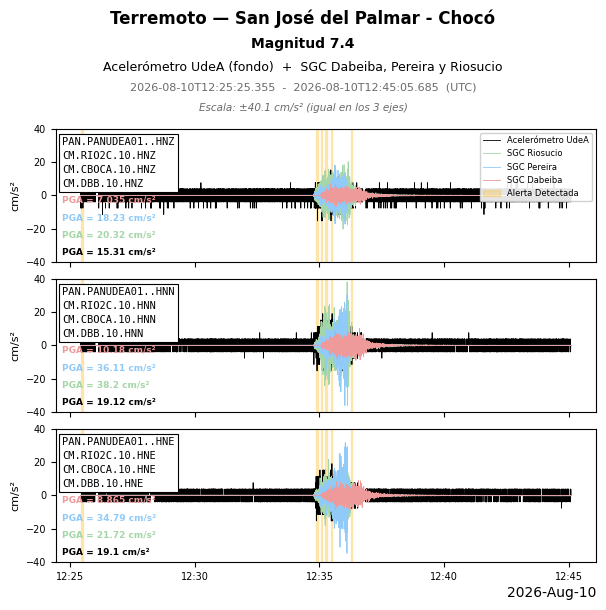

  guardado: data\Datos_SGC_Terremoto_Choco\comparacion_4_trazas_udea_sgc_UTC.png  (900x900 px)  [UTC]


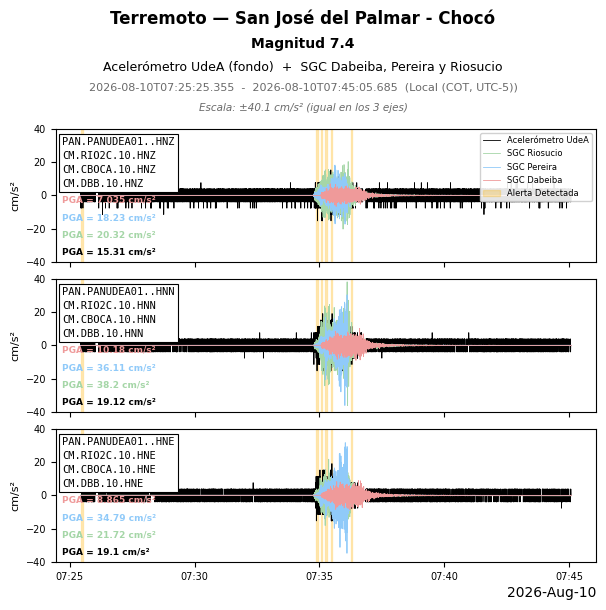

  guardado: data\Datos_SGC_Terremoto_Choco\comparacion_4_trazas_udea_sgc_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [74]:
serie_propia_todas = _serie_unidad(t_utc_propia_todas, data_g_propia_todas, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "cm/s²")
serie_dbb_todas = _serie_unidad(t_utc_mseed_dbb, mseed_dbb_cms2, ID_DABEIBA_MSEED, "SGC Dabeiba", COLOR_DABEIBA_TENUE, "cm/s²", "cm/s²")
serie_per_todas = _serie_unidad(t_utc_mseed, mseed_cms2, ID_PEREIRA_MSEED, "SGC Pereira", COLOR_PEREIRA_TENUE, "cm/s²", "cm/s²")
serie_rio_todas = _serie_unidad(t_utc_mseed_rio, mseed_rio_cms2, ID_RIOSUCIO_MSEED, "SGC Riosucio", COLOR_RIOSUCIO_TENUE, "cm/s²", "cm/s²")

serie_todas_combinada = _combinar(_combinar(_combinar(serie_propia_todas, serie_rio_todas), serie_per_todas), serie_dbb_todas)

plot_sgc_style(serie_todas_combinada, unidad="cm/s²",
               save_path=DIR_SGC_OUT / "comparacion_4_trazas_udea_sgc.png",
               estaciones=ESTACIONES_TODAS,
               alert_windows=recon["alert_windows"])


### Animación -- las 4 trazas (cm/s²)

In [75]:
crear_animacion_sgc_style(serie_todas_combinada, unidad="cm/s²",
    save_path=DIR_SGC_OUT / "comparacion_4_trazas_udea_sgc_animacion.gif",
    estaciones=ESTACIONES_TODAS,
    alert_windows=recon["alert_windows"],
    n_frames=50, fps=10)


  guardado: data\Datos_SGC_Terremoto_Choco\comparacion_4_trazas_udea_sgc_animacion_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: data\Datos_SGC_Terremoto_Choco\comparacion_4_trazas_udea_sgc_animacion_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


### Gráfica estática -- las 4 trazas (g)

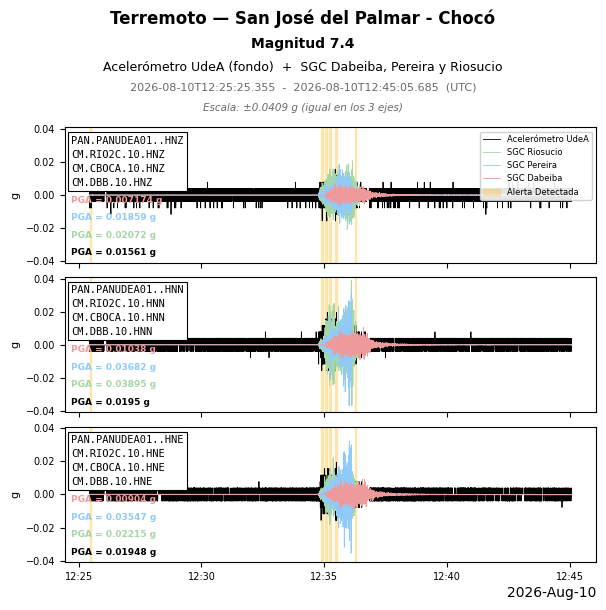

  guardado: data\Datos_SGC_Terremoto_Choco\comparacion_4_trazas_udea_sgc_g_UTC.png  (900x900 px)  [UTC]


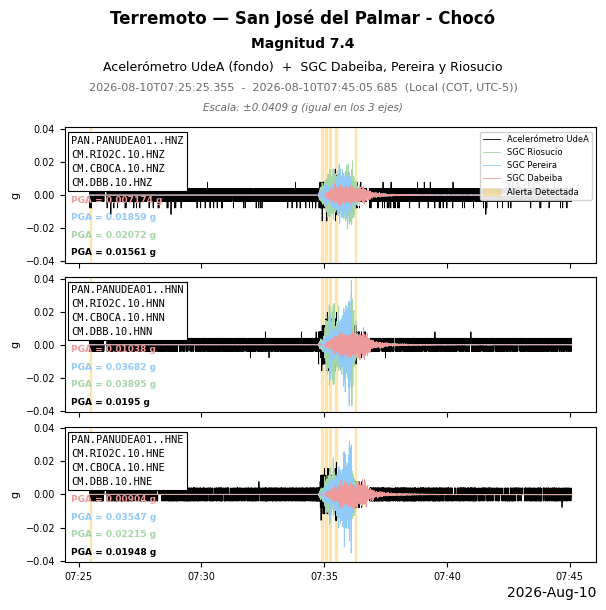

  guardado: data\Datos_SGC_Terremoto_Choco\comparacion_4_trazas_udea_sgc_g_LOCAL.png  (900x900 px)  [Local (COT, UTC-5)]


In [76]:
serie_propia_todas_g = _serie_unidad(t_utc_propia_todas, data_g_propia_todas, ID_PROPIA, "Acelerómetro UdeA", COLOR_PROPIA, "g", "g")
serie_dbb_todas_g = _serie_unidad(t_utc_mseed_dbb, mseed_dbb_cms2, ID_DABEIBA_MSEED, "SGC Dabeiba", COLOR_DABEIBA_TENUE, "cm/s²", "g")
serie_per_todas_g = _serie_unidad(t_utc_mseed, mseed_cms2, ID_PEREIRA_MSEED, "SGC Pereira", COLOR_PEREIRA_TENUE, "cm/s²", "g")
serie_rio_todas_g = _serie_unidad(t_utc_mseed_rio, mseed_rio_cms2, ID_RIOSUCIO_MSEED, "SGC Riosucio", COLOR_RIOSUCIO_TENUE, "cm/s²", "g")

serie_todas_combinada_g = _combinar(_combinar(_combinar(serie_propia_todas_g, serie_rio_todas_g), serie_per_todas_g), serie_dbb_todas_g)

plot_sgc_style(serie_todas_combinada_g, unidad="g",
               save_path=DIR_SGC_OUT / "comparacion_4_trazas_udea_sgc_g.png",
               estaciones=ESTACIONES_TODAS,
               alert_windows=recon["alert_windows"])


### Animación -- las 4 trazas (g)

In [77]:
crear_animacion_sgc_style(serie_todas_combinada_g, unidad="g",
    save_path=DIR_SGC_OUT / "comparacion_4_trazas_udea_sgc_animacion_g.gif",
    estaciones=ESTACIONES_TODAS,
    alert_windows=recon["alert_windows"],
    n_frames=50, fps=10)


  guardado: data\Datos_SGC_Terremoto_Choco\comparacion_4_trazas_udea_sgc_animacion_g_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: data\Datos_SGC_Terremoto_Choco\comparacion_4_trazas_udea_sgc_animacion_g_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


## §18 — Animación: solo el acelerómetro UdeA (hora completa)

Versión animada de la reconstrucción de la hora completa (§7), sin comparar
con ninguna estación del SGC -- reutiliza `_series_propia()` (ya definida en
§7) y las mismas franjas de alerta animadas que el resto de las animaciones
(§16/§17). En g y cm/s², UTC y hora local (automático).

In [ ]:
crear_animacion_sgc_style(
    _series_propia(recon, "g"), unidad="g",
    save_path=DIR_OUT_PLOTS / "terremoto_choco_reconstruccion_hora_completa_animacion_g.gif",
    estaciones=ESTACIONES_PROPIA + " (reconstrucción)",
    alert_windows=recon["alert_windows"],
)

crear_animacion_sgc_style(
    _series_propia(recon, "cm/s²"), unidad="cm/s²",
    save_path=DIR_OUT_PLOTS / "terremoto_choco_reconstruccion_hora_completa_animacion_cms2.gif",
    estaciones=ESTACIONES_PROPIA + " (reconstrucción)",
    alert_windows=recon["alert_windows"],
)


  guardado: output\plots\terremoto_choco_reconstruccion_hora_completa_animacion_g_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: output\plots\terremoto_choco_reconstruccion_hora_completa_animacion_g_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]


  guardado: output\plots\terremoto_choco_reconstruccion_hora_completa_animacion_cms2_UTC.gif  (50 cuadros, 10 fps)  [UTC]


  guardado: output\plots\terremoto_choco_reconstruccion_hora_completa_animacion_cms2_LOCAL.gif  (50 cuadros, 10 fps)  [Local (COT, UTC-5)]
